## **IPLGuru: Hybrid RAG Assistant for IPL Analytics**

### **Introduction**
The Indian Premier League (IPL) is more than just a cricket tournament; it is a grand spectacle that combines sports, entertainment, and fan passion. Since its inception in 2008, the IPL has captivated audiences globally with thrilling matches, star-studded teams, and unforgettable moments. It has grown into one of the most celebrated T20 leagues, blending high-octane action with strategic brilliance and cultural vibrancy.

IPLGuru is an AI-powered cricket analytics assistant designed to answer IPL-related questions using a hybrid retrieval architecture.
</br>
The system combines structured data retrieval from MySQL with semantic retrieval from ChromaDB and dynamically routes user queries to the most appropriate source using LLM-based query classification.
</br>
By integrating LlamaIndex, LangChain, OpenAI models, MySQL, and ChromaDB, IPLGuru provides accurate, context-aware, and conversational responses to both statistical and narrative IPL queries.


### **Business Problem**
IPL data exists in both structured and unstructured forms.
</br>
Structured questions such as player statistics and match results are best answered using SQL queries, while broader conversational questions require semantic understanding and contextual retrieval.
</br>
Traditional search systems struggle to handle both query types within a unified interface.
</br>
The objective of IPLGuru is to build a hybrid AI assistant capable of intelligently routing queries and retrieving information from the appropriate knowledge source while maintaining conversational context.

### **Objective**
To conceptualize, design, develop, and implement a tailored AI-driven project that demonstrates the seamless integration and powerful capabilities of LlamaIndex and LangChain. This project aims to highlight their synergy in building intelligent systems capable of efficient data retrieval, context retention, and insightful responses.







### **Design**

The objective of this project is to develop an AI-driven application capable of seamlessly answering user queries about the IPL. The following components form the foundation of the application: </br>
1. Data Ingestion and Cleaning </br>
2. Exploratory Data Analysis (EDA) </br>
3. Data Integration into MySQL Database</br>
4.	Embedding and Indexing Leveraging LlamaIndex</br>
5.	Development of an SQL Search Agent</br>
6.	Implementation of a Search Agent for the Vector Database</br>
7.	Design of an Intelligent Query Router</br>
8.	Memory Management and Context Retention with LangChain
</br>
Each component plays a vital role in processing and understanding the source material, optimizing query matching, and generating coherent answers.

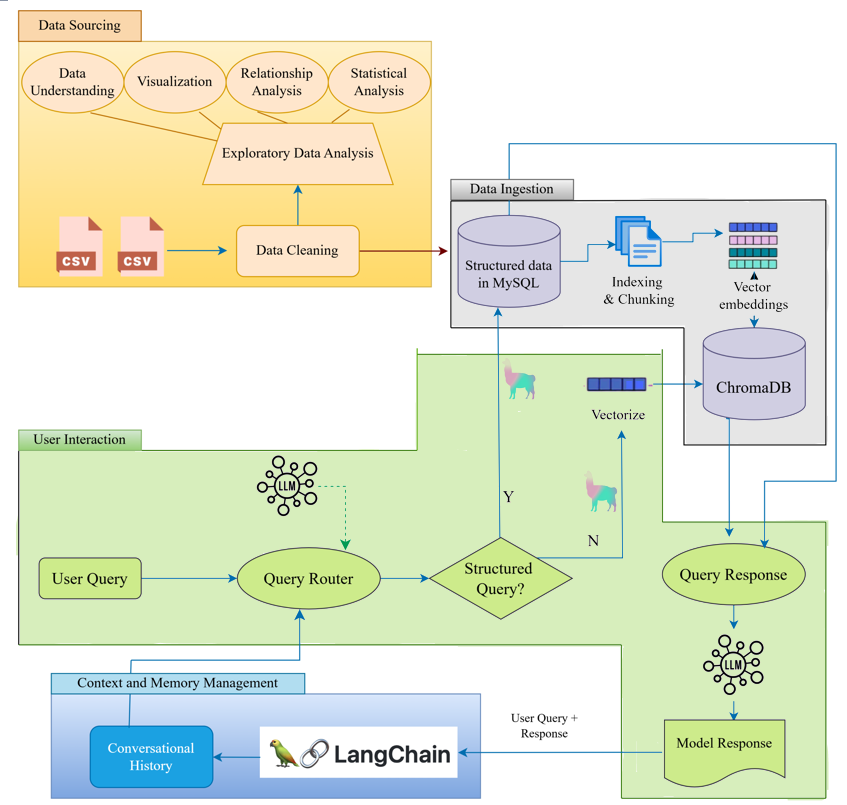

In [2]:
# Specify the path to your image
from IPython.display import Image
image_path = '../reports/figures/system_architecture.png'  # Replace with your image path

# Display the image
display(Image(filename=image_path))

### **1. Installing required dependencies and importing the libraries**

##### 1.1 Importing basic libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

##### 1.2 Import statements for storing API key

In [2]:
import openai
import os

In [23]:
openai.api_key = open("/content/drive/MyDrive/Project_data/IPLGuru/OpenAPIKey.txt", "r").read().strip()
os.environ['OPENAI_API_KEY'] = openai.api_key

##### 1.3 Import for MySQL data insertion

In [3]:
!pip install mysqlclient

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mysqlclient: filename=mysqlclient-2.2.6-cp310-cp310-linux_x86_64.whl size=125252 sha256=956cf2e2b41d3854a82097ad22da483844c946e93ed4b517c2bcc72cfdfcfea4
  Stored in directory: /root/.cache/pip/wheels/c0/95/75/9ec8105309b2316e3e5eb4d3f661fa392f1bef34597232cef9
Successfully built mysqlclient


In [4]:
import sqlalchemy
from sqlalchemy import create_engine, MetaData, Table, Column, Integer, String, Float, ForeignKey
from sqlalchemy import text
from sqlalchemy.types import Text
import urllib.parse
import logging

##### 1.4 Import for storing embeddings into ChromaDB

In [5]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 26.0 MB/s eta 0:00:00


In [6]:
!pip install llama_index==0.11.23

INFO: pip is looking at multiple versions of llama-index-indices-managed-llama-cloud to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of llama-index-readers-llama-parse to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.0/298.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.7 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.0.0
    Uninstalling tenacity-9.0.0:
      Successfully uninstalled tenacity-9.0.0


In [7]:
!pip install chromadb==0.5.18

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.6/278.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 1.7 MB/s eta 0:00:00


In [8]:
import mysql.connector
from tqdm import tqdm  # For progress tracking

In [9]:
!pip install langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.2 MB/s eta 0:00:00
  Attempting uninstall: SQLAlchemy
    Found existing installation: SQLAlchemy 2.0.36
    Uninstalling SQLAlchemy-2.0.36:
      Successfully uninstalled SQLAlchemy-2.0.36


In [10]:
#from llama_index.core import VectorStoreIndex, Document, ServiceContext
from llama_index.embeddings.openai import OpenAIEmbedding
from llama_index.core import Document
from langchain.vectorstores import Chroma
from tqdm import tqdm
from chromadb.config import Settings
from chromadb import Client

In [11]:
import chromadb
from chromadb.config import Settings
from chromadb import Client

##### 1.5 Import for querying from MySQL using LlamaIndex

In [12]:
!pip install llama-hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.9/103.9 MB 7.0 MB/s eta 0:00:00
  Created wheel for html2text: filename=html2text-2024.2.26-py3-none-any.whl size=33111 sha256=323b80c4c4f5a8a23e17a821adff6cac9f9cd932b1af53b58b31f3b2f7d0120d
  Stored in directory: /root/.cache/pip/wheels/f3/96/6d/a7eba8f80d31cbd188a2787b81514d82fc5ae6943c44777659
Successfully built html2text


In [13]:
from llama_index.core import ServiceContext, SQLDatabase
from llama_index.core.indices.struct_store import GPTSQLStructStoreIndex, SQLStructStoreIndex
from llama_index.core.data_structs.table import SQLStructTable

In [14]:
from llama_index.core import Settings
from llama_index.embeddings.openai import OpenAIEmbedding
from llama_index.core.node_parser import SentenceSplitter
from llama_index.llms.openai import OpenAI

In [15]:
from llama_index.core.prompts import PromptTemplate
from llama_index.core.prompts import BasePromptTemplate
from llama_index.core.indices.vector_store.base import GPTVectorStoreIndex
from langchain.chat_models import ChatOpenAI
from sqlalchemy.orm import sessionmaker

In [16]:
!pip install llama-index-vector-stores-chroma

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.2 MB/s eta 0:00:00
  Attempting uninstall: llama-index-core
    Found existing installation: llama-index-core 0.11.23
    Uninstalling llama-index-core-0.11.23:
      Successfully uninstalled llama-index-core-0.11.23
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llama-index 0.11.23 requires llama-index-core<0.12.0,>=0.11.23, but you have llama-index-core 0.12.1 which is incompatible.
llama-index-agent-openai 0.3.4 requires llama-index-core<0.12.0,>=0.11.0, but you have llama-index-core 0.12.1 which is incompatible.
llama-index-cli 0.3.1 requires llama-index-core<0.12.0,>=0.11.0, but you have llama-index-core 0.12.1 which is incompatible.
llama-index-embeddings-openai 0.2.5 requires llama-index-core<0.12.0,>=0.11.0, but you have llama-index-core 0.12.1 which is incompatible.
llama-index-indices-managed-

In [17]:
!pip install sqlalchemy mysql-connector-python

##### 1.6 Import for querying data from Vector store using Llama-index

In [18]:
from llama_index.core import VectorStoreIndex,StorageContext,SimpleKeywordTableIndex
from llama_index.core.query_engine import RetrieverQueryEngine
from chromadb.config import Settings
from llama_index.vector_stores.chroma import ChromaVectorStore


##### 1.7 Import statements for Intelligent Query routing

In [19]:
from langchain.chat_models import ChatOpenAI
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain

##### 1.8 Import statements for conversation flow and memory management

In [20]:
!pip install langchain-experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.0/209.0 kB 3.8 MB/s eta 0:00:00


In [21]:
from langchain.chains import ConversationalRetrievalChain
from langchain_experimental.sql import SQLDatabaseChain
from langchain.memory import ConversationBufferMemory

### **2. Data Sourcing & Cleaning**

##### 2.1 Load complete IPL data from CSV file to Python dataframe

In [ ]:
matches_df = pd.read_csv("/content/drive/MyDrive/Project_data/IPLGuru/matches.csv", engine='python')
deliveries_df = pd.read_csv("/content/drive/MyDrive/Project_data/IPLGuru/deliveries.csv", engine='python')

In [ ]:
print("shape of matches dataframe:", matches_df.shape)
print("shape of deliveries dataframe:", deliveries_df.shape)

shape of matches dataframe: (1095, 20)
shape of deliveries dataframe: (260920, 17)


In [ ]:
matches_df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
deliveries_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [ ]:
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [ ]:
deliveries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

##### 2.2 Checking for duplicate values

In [ ]:
matches_df.duplicated().sum()

0

In [ ]:
deliveries_df.duplicated().sum()

0

*No Duplicate Records found*

##### 2.3 Handling Missing values

In [ ]:
matches_df.isna().sum().loc[lambda x : x>0]

,0
city,51
player_of_match,5
winner,5
result_margin,19
target_runs,3
target_overs,3
method,1074


Handling NULL values in 'City'

In [ ]:
matches_df[matches_df['city'].isna()]['venue'].unique()

array(['Sharjah Cricket Stadium', 'Dubai International Cricket Stadium'],
      dtype=object)

In [ ]:
matches_df.loc[(matches_df['city'].isna()) & (matches_df['venue']=="Sharjah Cricket Stadium"),'city'] = "Sharjah"
matches_df.loc[(matches_df['city'].isna()) & (matches_df['venue']=="Dubai International Cricket Stadium"),'city'] = "Dubai"

In [ ]:
matches_df['city'].isna().sum()

0

Handling NULL values in 'Winner'

In [ ]:
matches_df[matches_df['winner'].isna()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


As we could see from above, these 5 rows doesn't depict any useful information

In [ ]:
deliveries_df[deliveries_df.match_id.isin([501265,829763,829813,1178424,1359519])].groupby('match_id')['match_id'].count()

,match_id
match_id,
501265,63
829763,128
829813,130
1178424,51
1359519,118


In [ ]:
matches_df[matches_df['winner'].notna()].head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
deliveries_df[deliveries_df.match_id.isin([335982,335983,335984,335985,335986])].groupby('match_id')['match_id'].count()

,match_id
match_id,
335982,225
335983,248
335984,219
335985,246
335986,240


AS we could clearly see that normal matches will have more than 200 deliveries for the match. For the records with no Winner or player of the match, we could clearly see that no. of deliveries is very less indicating that the match might have in stopped in the middle and hence these NAN values are legitimate, which should not be replaced.

Handling NULL values in 'result_margin'

In [ ]:
matches_df[matches_df['result_margin'].isna()]['result'].unique()

array(['tie', 'no result'], dtype=object)

In all these cases, result of  the match is either 'Tie' or 'no result'. Hence these NULL values are valid

Handling NULL values in 'target_runs' and 'target_overs'

In [ ]:
matches_df[matches_df['target_runs'].isna()]['result'].unique()

array(['no result'], dtype=object)

In [ ]:
matches_df[matches_df['target_overs'].isna()]['result'].unique()

array(['no result'], dtype=object)

We see that match has stopped in the middle and hence these values are NULL, which is valid

Handling NULL values for 'method' column

In [ ]:
matches_df.groupby(by='method')['method'].count()

,method
method,
D/L,21


D/L is the Duckworth-Lewis method to calculate the winning side in a cricket match that has been interrupted by rain or other inclement weather. Since only 21 records has entry for this, retaining this column has no special significance. Hence removing this from dataset

In [ ]:
matches_df = matches_df.drop('method', axis=1)

In [ ]:
matches_df.isna().sum().loc[lambda x : x>0]

,0
player_of_match,5
winner,5
result_margin,19
target_runs,3
target_overs,3


##### 2.4 Handling Data format Consistency

Handling Inconsistent data format in 'season' column

In [ ]:
matches_df['season'].unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

In [ ]:
matches_df.replace({"season":{"2007/08":"2008","2009/10":"2010","2020/21":"2020"}},inplace=True)

In [ ]:
matches_df['season'].unique()

array(['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'], dtype=object)

##### 2.5 Handling Redundant values

Handling redundant values in 'Team' column

In [ ]:
team1_array = sorted(matches_df['team1'].unique())
team1_array

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Delhi Daredevils',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kings XI Punjab',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiant',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

In [ ]:
teams_replace_dict = {"Royal Challengers Bangalore":"Royal Challengers Bengaluru",
 "Delhi Daredevils":"Delhi Capitals",
 "Kings XI Punjab":"Punjab Kings",
 "Deccan Chargers":"Sunrisers Hyderabad",
 "Gujarat Lions":"Gujarat Titans",
 "Rising Pune Supergiants":"Rising Pune Supergiant",
 "Pune Warriors":"Rising Pune Supergiant",
}


In [ ]:
matches_df[['team1','team2','toss_winner','winner']] = matches_df[['team1','team2','toss_winner','winner']].replace(teams_replace_dict)

deliveries_df[['batting_team','bowling_team']] = deliveries_df[['batting_team','bowling_team']].replace(teams_replace_dict)

Handling redundant values in 'venue' column

In [ ]:
venue_array = sorted(matches_df['venue'].unique())
venue_array

['Arun Jaitley Stadium',
 'Arun Jaitley Stadium, Delhi',
 'Barabati Stadium',
 'Barsapara Cricket Stadium, Guwahati',
 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow',
 'Brabourne Stadium',
 'Brabourne Stadium, Mumbai',
 'Buffalo Park',
 'De Beers Diamond Oval',
 'Dr DY Patil Sports Academy',
 'Dr DY Patil Sports Academy, Mumbai',
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam',
 'Dubai International Cricket Stadium',
 'Eden Gardens',
 'Eden Gardens, Kolkata',
 'Feroz Shah Kotla',
 'Green Park',
 'Himachal Pradesh Cricket Association Stadium',
 'Himachal Pradesh Cricket Association Stadium, Dharamsala',
 'Holkar Cricket Stadium',
 'JSCA International Stadium Complex',
 'Kingsmead',
 'M Chinnaswamy Stadium',
 'M Chinnaswamy Stadium, Bengaluru',
 'M.Chinnaswamy Stadium',
 'MA Chidambaram Stadium',
 'MA Chidambaram Stadium, Chepauk',
 'MA Chidambaram Stadium, Chepauk, Chennai',
 'Maharaja

In [ ]:
venue_replace_dict = {'Arun Jaitley Stadium' : 'Arun Jaitley Stadium, Delhi',
'Brabourne Stadium' : 'Brabourne Stadium, Mumbai',
'Dr DY Patil Sports Academy' : 'Dr DY Patil Sports Academy, Mumbai',
'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium' : 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam',
'Eden Gardens' : 'Eden Gardens, Kolkata',
'Himachal Pradesh Cricket Association Stadium' : 'Himachal Pradesh Cricket Association Stadium, Dharamsala',
'M Chinnaswamy Stadium' : 'M Chinnaswamy Stadium, Bengaluru',
'M.Chinnaswamy Stadium' : 'M Chinnaswamy Stadium, Bengaluru',
'MA Chidambaram Stadium' : 'MA Chidambaram Stadium, Chepauk, Chennai',
'MA Chidambaram Stadium, Chepauk' : 'MA Chidambaram Stadium, Chepauk, Chennai',
'Maharashtra Cricket Association Stadium' : 'Maharashtra Cricket Association Stadium, Pune',
'Punjab Cricket Association IS Bindra Stadium' : 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh',
'Punjab Cricket Association IS Bindra Stadium, Mohali' : 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh',
'Punjab Cricket Association Stadium, Mohali' : 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh',
'Rajiv Gandhi International Stadium' : 'Rajiv Gandhi International Stadium, Uppal, Hyderabad',
'Rajiv Gandhi International Stadium, Uppal' : 'Rajiv Gandhi International Stadium, Uppal, Hyderabad',
'Sawai Mansingh Stadium' : 'Sawai Mansingh Stadium, Jaipur',
'Wankhede Stadium' : 'Wankhede Stadium, Mumbai'
}

In [ ]:
matches_df.replace({"venue":venue_replace_dict},inplace=True)

In [ ]:
venue_array = sorted(matches_df['venue'].unique())
venue_array

['Arun Jaitley Stadium, Delhi',
 'Barabati Stadium',
 'Barsapara Cricket Stadium, Guwahati',
 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow',
 'Brabourne Stadium, Mumbai',
 'Buffalo Park',
 'De Beers Diamond Oval',
 'Dr DY Patil Sports Academy, Mumbai',
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam',
 'Dubai International Cricket Stadium',
 'Eden Gardens, Kolkata',
 'Feroz Shah Kotla',
 'Green Park',
 'Himachal Pradesh Cricket Association Stadium, Dharamsala',
 'Holkar Cricket Stadium',
 'JSCA International Stadium Complex',
 'Kingsmead',
 'M Chinnaswamy Stadium, Bengaluru',
 'MA Chidambaram Stadium, Chepauk, Chennai',
 'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur',
 'Maharashtra Cricket Association Stadium, Pune',
 'Narendra Modi Stadium, Ahmedabad',
 'Nehru Stadium',
 'New Wanderers Stadium',
 'Newlands',
 'OUTsurance Oval',
 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh',
 'Rajiv Gandhi Intern

### **3. Exploratory Data Analysis**

##### 3.1 Trend of Total number of matches over season

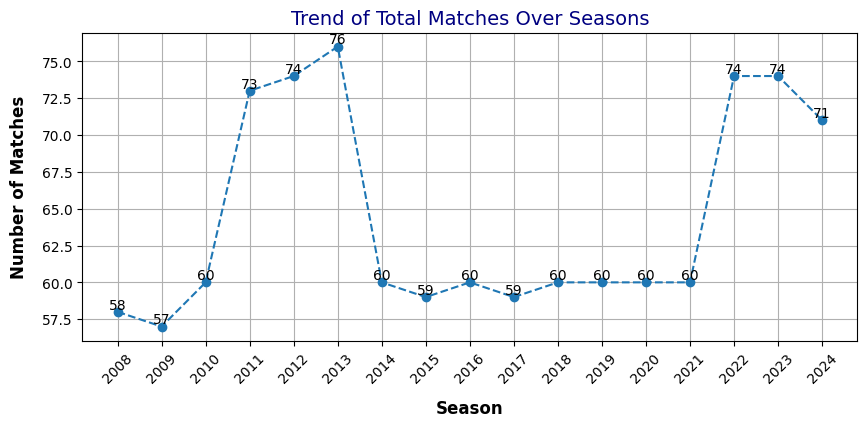

In [ ]:
season_counts = matches_df['season'].value_counts().sort_index()

# Ploting the trend as a line chart
plt.figure(figsize=(10, 4))
plt.plot(season_counts.index, season_counts.values, marker='o', linestyle='--')

# Adding titles and labels
plt.title('Trend of Total Matches Over Seasons', fontdict={"fontsize":14, "fontweight":5,"color":"#000080"})
plt.xlabel('Season', labelpad=10,fontweight='bold',fontsize=12)
plt.ylabel('Number of Matches', labelpad=10,fontweight='bold',fontsize=12)

# Annotating each data point with the value
for i, value in enumerate(season_counts.values):
    plt.text(season_counts.index[i], value, str(value), fontsize=10, ha='center', va='bottom')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

##### 3.2 Matches hosted by each city

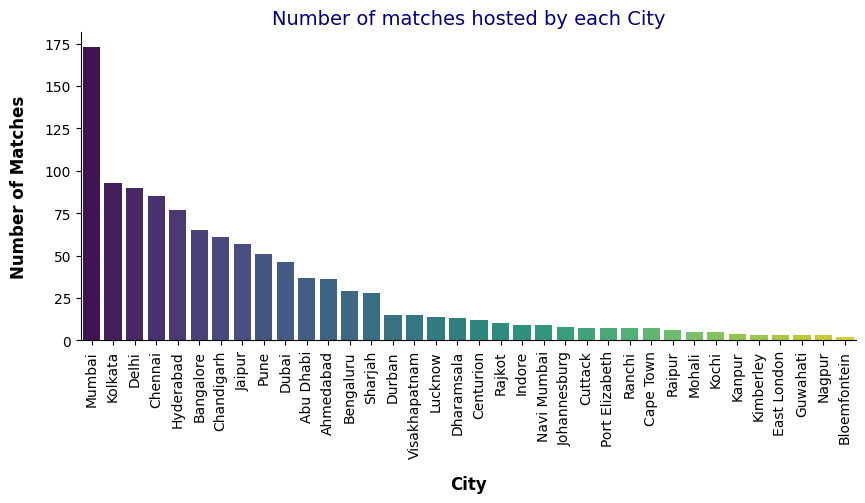

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(data=matches_df, x='city',  order=matches_df['city'].value_counts().index, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel("City", fontweight='bold')
plt.ylabel('Number of Matches',fontweight='bold')
plt.title('Number of matches hosted by each City',fontdict={"fontsize":14, "fontweight":5,"color":"#000080"})
plt.rc('axes', titlesize=14,labelpad=12)
plt.rc('axes', labelsize=12,labelpad=12)

gca = plt.gca()
gca.spines['top'].set_visible(False)
gca.spines['right'].set_visible(False)

plt.show()

##### 3.3 Percentage of Matches won by Toss decision

In [ ]:
# Grouping by toss decision and counting how often each decision leads to a win
wins_by_decision = matches_df.groupby('toss_decision').size().reset_index(name='wins')

# Calculating the percentage of matches won by teams batting first vs. fielding first
total_matches = matches_df.shape[0]
wins_by_decision['percentage'] = round ((wins_by_decision['wins'] / total_matches) * 100,2)

# Displaying the result
print(wins_by_decision)

  toss_decision  wins  percentage
0           bat   391       35.71
1         field   704       64.29


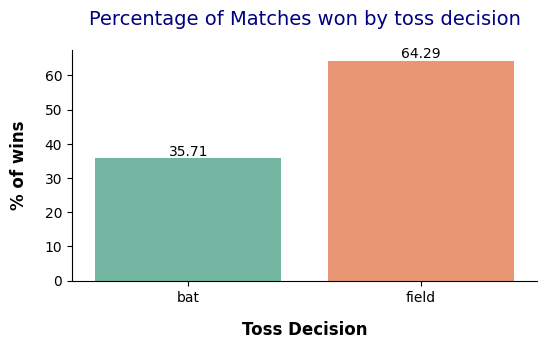

In [ ]:
plt.figure(figsize=(6,3))
barplotresult = sns.barplot(data=wins_by_decision, x="toss_decision", y="percentage", palette='Set2')
#Add labels to Bar
for i in barplotresult.containers:
    barplotresult.bar_label(i,fontsize=10)
plt.xlabel('Toss Decision',fontweight='bold')
plt.ylabel('% of wins',fontweight='bold')
plt.rc('axes', titlesize=14,labelpad=12)
plt.rc('axes', labelsize=12,labelpad=12)
plt.title('Percentage of Matches won by toss decision',pad=18,fontdict={"fontsize":14, "fontweight":5,"color":"#000080"})
gca = plt.gca()
gca.spines['top'].set_visible(False)
gca.spines['right'].set_visible(False)

plt.show()

##### 3.4 Top 10 players with most Player of the match awards

In [ ]:
player_counts = matches_df['player_of_match'].value_counts().head(10)
player_counts.values

array([25, 22, 19, 18, 18, 17, 16, 16, 16, 15])

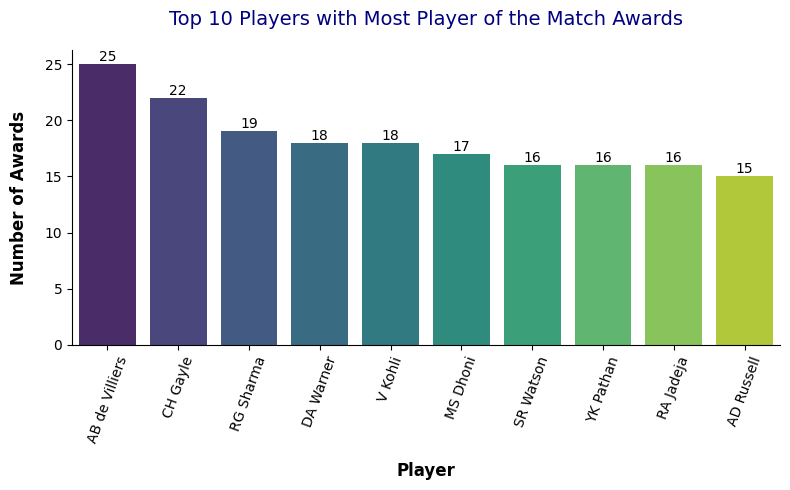

In [ ]:
plt.figure(figsize=(8,5))

countplotresult = sns.countplot(data=matches_df, x='player_of_match',  order=matches_df['player_of_match'].value_counts().iloc[:10].index, palette='viridis')
#Add labels to Bar
for i in countplotresult.containers:
    countplotresult.bar_label(i,fontsize=10)

plt.title('Top 10 Players with Most Player of the Match Awards',pad=18,fontdict={"fontsize":14, "fontweight":5,"color":"#000080"})
plt.xlabel('Player',fontweight='bold')
plt.ylabel('Number of Awards',fontweight='bold')

plt.xticks(rotation=70)
plt.tight_layout()
gca = plt.gca()
gca.spines['top'].set_visible(False)
gca.spines['right'].set_visible(False)

plt.show()

##### 3.5 Top 10 players with most runs in IPL history

In [ ]:
player_runs_df = deliveries_df[['batter', 'batsman_runs']]
player_runs_df = player_runs_df.groupby('batter')['batsman_runs'].sum().reset_index(name='total_runs')
player_runs_df

,batter,total_runs
0,A Ashish Reddy,280
1,A Badoni,634
2,A Chandila,4
3,A Chopra,53
4,A Choudhary,25
...,...,...
668,Yashpal Singh,47
669,Younis Khan,3
670,Yudhvir Singh,22
671,Yuvraj Singh,2754


In [ ]:
top_players_df = player_runs_df.sort_values(by='total_runs', ascending=False).head(10)
top_players_df

,batter,total_runs
631,V Kohli,8014
512,S Dhawan,6769
477,RG Sharma,6630
147,DA Warner,6567
546,SK Raina,5536
374,MS Dhoni,5243
30,AB de Villiers,5181
124,CH Gayle,4997
501,RV Uthappa,4954
282,KD Karthik,4843


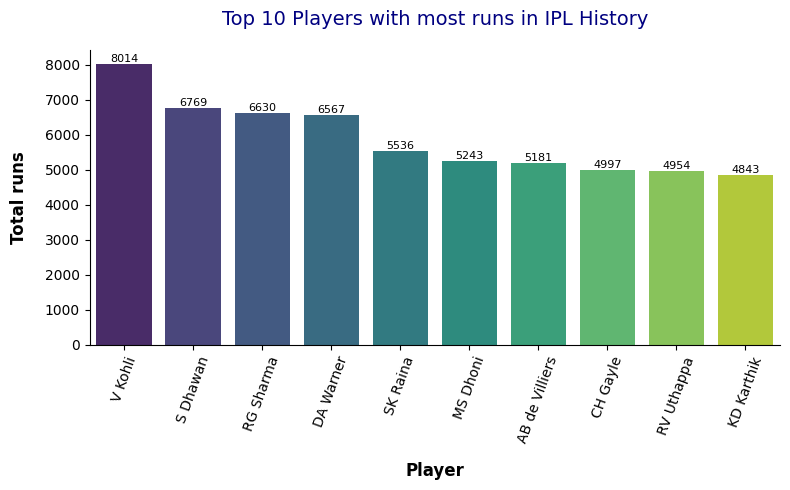

In [ ]:
plt.figure(figsize=(8,5))

barplotresult = sns.barplot(data=top_players_df, x='batter', y='total_runs', palette='viridis')

#Add labels to Bar
for i in barplotresult.containers:
    barplotresult.bar_label(i,fontsize=8)

plt.title('Top 10 Players with most runs in IPL History',pad=18,fontdict={"fontsize":14, "fontweight":5,"color":"#000080"})
plt.xlabel('Player',fontweight='bold')
plt.ylabel('Total runs',fontweight='bold')

plt.xticks(rotation=70)
plt.tight_layout()
gca = plt.gca()
gca.spines['top'].set_visible(False)
gca.spines['right'].set_visible(False)

plt.show()

##### 3.6 Top 10 batsman with highest average runs per match

In [ ]:
batter_data= deliveries_df[['match_id','batter','batsman_runs']]

batter_matches = batter_data.groupby('batter')['match_id'].nunique().reset_index(name='matches_played')

batter_total_runs = batter_data.groupby('batter')['batsman_runs'].sum().reset_index(name='total_runs')

batter_summary = pd.merge(batter_matches, batter_total_runs, on='batter')

batter_summary['Avg_runs'] = batter_summary['total_runs'] / batter_summary['matches_played']

batter_summary = batter_summary[batter_summary['matches_played']>=25]

batter_avg = batter_summary.sort_values(by='Avg_runs', ascending=False).reset_index(drop=True)

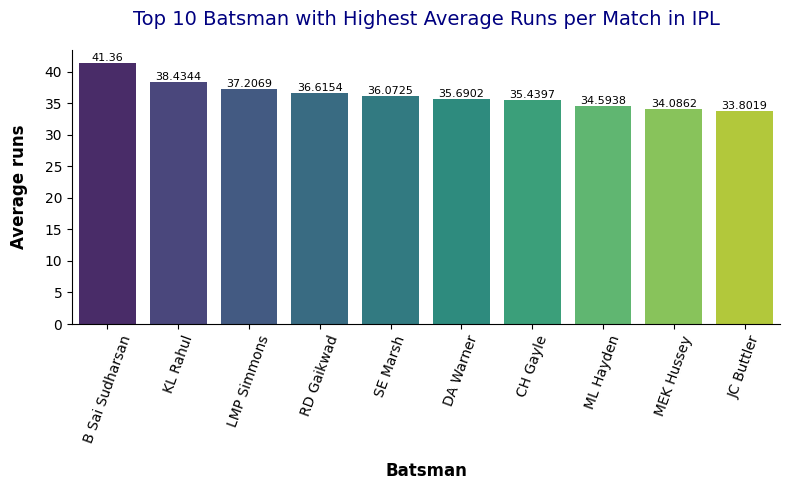

In [ ]:
plt.figure(figsize=(8,5))

barplotresult = sns.barplot(data=batter_avg.head(10), x='batter', y='Avg_runs', palette='viridis')

#Add labels to Bar
for i in barplotresult.containers:
    barplotresult.bar_label(i,fontsize=8)

plt.title('Top 10 Batsman with Highest Average Runs per Match in IPL',pad=18,fontdict={"fontsize":14, "fontweight":5,"color":"#000080"})
plt.xlabel('Batsman',fontweight='bold')
plt.ylabel('Average runs',fontweight='bold')

plt.xticks(rotation=70)
plt.tight_layout()
gca = plt.gca()
gca.spines['top'].set_visible(False)
gca.spines['right'].set_visible(False)

plt.show()

##### 3.7 Top 10 wicket takers in IPL History

In [ ]:
most_wicket_taker = deliveries_df[['bowler', 'is_wicket']]
most_wicket_taker = most_wicket_taker.groupby('bowler')['is_wicket'].sum().reset_index(name='total_wicket')
most_wicket_taker = most_wicket_taker.sort_values(by='total_wicket', ascending=False).reset_index(drop=True)

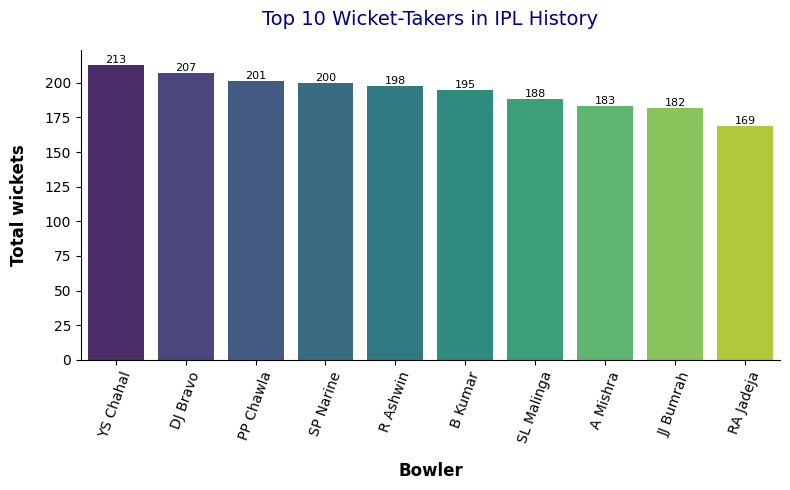

In [ ]:
plt.figure(figsize=(8,5))

barplotresult = sns.barplot(data=most_wicket_taker.head(10), x='bowler', y='total_wicket', palette='viridis')

#Add labels to Bar
for i in barplotresult.containers:
    barplotresult.bar_label(i,fontsize=8)

plt.title('Top 10 Wicket-Takers in IPL History',pad=18,fontdict={"fontsize":14, "fontweight":5,"color":"#000080"})
plt.xlabel('Bowler',fontweight='bold')
plt.ylabel('Total wickets',fontweight='bold')

plt.xticks(rotation=70)
plt.tight_layout()
gca = plt.gca()
gca.spines['top'].set_visible(False)
gca.spines['right'].set_visible(False)

plt.show()

##### 3.8 Distribution of wins by Team over batting and chasing

In [ ]:
#total match played by team
total_matches= (matches_df['team1'].value_counts()+matches_df['team2'].value_counts()).rename_axis('Team').reset_index(name="Total_Match_Played")
# Count of wins for each team
total_wins = matches_df['winner'].value_counts().rename_axis('Team').reset_index(name='Total_Wins')

# Count of wins when chasing a target
team_chasing = matches_df[matches_df['toss_decision'] == 'field']['winner'].value_counts().rename_axis('Team').reset_index(name='Chasing_Wins')

# Count of wins when batting first
team_batting_first = matches_df[matches_df['toss_decision'] == 'bat']['winner'].value_counts().rename_axis('Team').reset_index(name='Batting_First_Wins')


# Merge all the DataFrames
merged_df = total_matches.merge(total_wins,on='Team',how='outer') \
    .merge(team_chasing, on='Team', how='outer') \
    .merge(team_batting_first, on='Team', how='outer')


# Fill NaN values with 0
merged_df= merged_df.fillna(0)
#sorting by total match played
merged_df.sort_values(by='Total_Match_Played', ascending=False, inplace=True)

In [ ]:
merged_df.set_index('Team', drop=True).sort_values(by='Total_Wins', ascending=False)
merged_df

,Team,Total_Match_Played,Total_Wins,Chasing_Wins,Batting_First_Wins
6,Mumbai Indians,261,144,90,54.0
11,Sunrisers Hyderabad,257,117,73,44.0
10,Royal Challengers Bengaluru,255,123,85,38.0
1,Delhi Capitals,252,115,73,42.0
4,Kolkata Knight Riders,251,131,81,50.0
7,Punjab Kings,246,112,84,28.0
0,Chennai Super Kings,238,138,75,63.0
8,Rajasthan Royals,221,112,69,43.0
9,Rising Pune Supergiant,76,27,16,11.0
2,Gujarat Titans,75,41,30,11.0


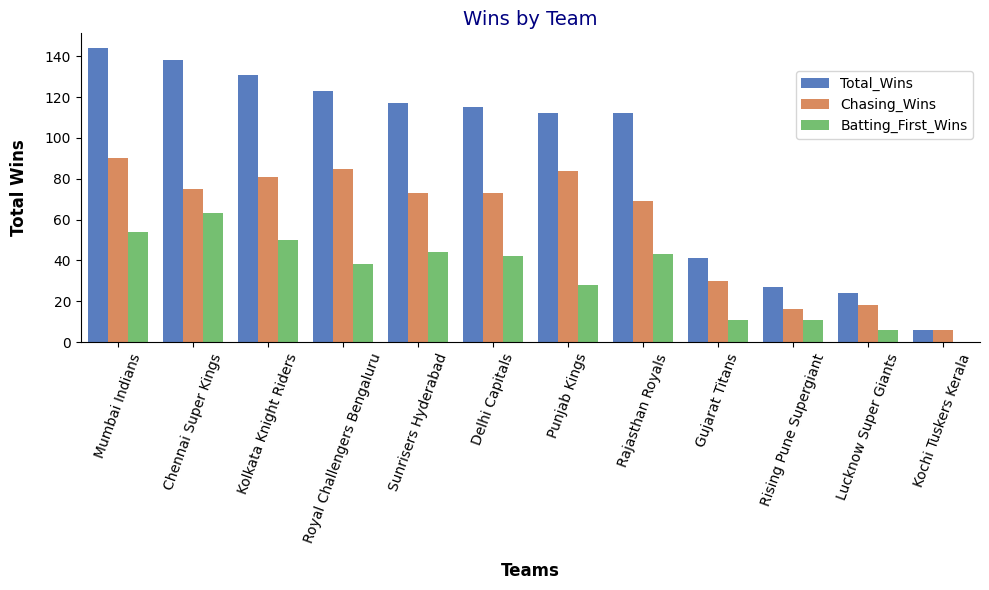

In [ ]:
# Melting the DataFrame for easier plotting
melted_df = merged_df.sort_values(by='Total_Wins', ascending=False).melt(id_vars='Team',
                                value_vars=['Total_Wins', 'Chasing_Wins', 'Batting_First_Wins'],
                                var_name='Win_Type',
                                value_name='Percentage')

# Creating a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=melted_df, x='Team', y='Percentage', hue='Win_Type', palette='muted')

# Adding labels and title
plt.xlabel('Teams', fontsize=12,fontweight='bold')
plt.ylabel('Total Wins', fontsize=12,fontweight='bold')
plt.title('Wins by Team',fontdict={"fontsize":14, "fontweight":5,"color":"#000080"})
plt.legend(bbox_to_anchor=(1.0, 0.9), fontsize=10)
plt.xticks(rotation=70)
plt.tight_layout()

gca = plt.gca()
gca.spines['top'].set_visible(False)
gca.spines['right'].set_visible(False)

plt.show()

### **4. Database setup and Ingestion**

Although the original data source comprises CSV files, this application incorporates a MySQL database as the primary datastore to handle structured queries. This approach, instead of directly utilizing Pandas DataFrames, is designed to demonstrate the integration and functionality of LlamaIndex with MySQL, aligning with real-world scenarios where structured databases like MySQL are predominantly utilized in enterprise-grade applications.

##### 4.1 MySQL server configurations

In [24]:
MYSQL_USER = ''
MYSQL_PASSWORD = ''
MYSQL_HOST = ''
MYSQL_PORT = 22039
MYSQL_DATABASE = 'ipldb'
# URL-encode the password to escape special characters like '@'
encoded_password = urllib.parse.quote_plus(MYSQL_PASSWORD)

In [25]:
# Create a connection to the MySQL database
engine = create_engine(f'mysql://{MYSQL_USER}:{encoded_password}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}')
metadata = MetaData()

##### 4.2 Test MySQL server connection

In [28]:
insp = sqlalchemy .inspect(engine)
db_list = insp.get_schema_names()
print(db_list)

['defaultdb', 'information_schema', 'ipldb', 'ipldb_test', 'mysql', 'performance_schema', 'sys']


##### 4.3 Get column types from pandas dataframe


In [ ]:
def infer_sqlalchemy_column_type(dtype):
    """
    Map Pandas dtypes to SQLAlchemy column types.
    """
    if pd.api.types.is_integer_dtype(dtype):
        return Integer
    elif pd.api.types.is_float_dtype(dtype):
        return Float
    elif pd.api.types.is_string_dtype(dtype):
        return Text  # Use Text for longer strings
    else:
        return String(255)  # Default to String

##### 4.4 Create MySQL tables from Pandas dataframe

In [ ]:
def create_table_from_dataframe(df, table_name, metadata, primary_key=None, foreign_key=None):
    """
    Dynamically create a SQLAlchemy Table from a DataFrame.
    - df: Pandas DataFrame
    - table_name: Name of the SQL table
    - metadata: SQLAlchemy MetaData object
    - foreign_key: Optional tuple of (column_name, referenced_table.referenced_column)
    - primary_key: The name of the column to use as a primary key (optional).
    """
    columns = []
    if primary_key is None:
        # Add an auto-increment primary key column if not provided
        columns.append(Column('id', Integer, primary_key=True, autoincrement=True))

    for col_name, dtype in zip(df.columns, df.dtypes):
        column_type = infer_sqlalchemy_column_type(dtype)
        if primary_key and col_name == primary_key:
            # Add a primary key column
            columns.append(Column(col_name, column_type, primary_key=True))
        elif foreign_key and col_name == foreign_key[0]:
            # Add foreign key if the column matches
            columns.append(Column(col_name, column_type, ForeignKey(f"{foreign_key[1]}")))
        else:
            # Add a regular column
            columns.append(Column(col_name, column_type))

    # Define the table
    table = Table(table_name, metadata, *columns)
    return table

##### 4.5 Create MySQL tables dynamically

In [ ]:
# Define primary key columns for both tables
matches_primary_key = 'id'
deliveries_primary_key = None

In [ ]:
# Create tables dynamically
matches_table = create_table_from_dataframe(matches_df, 'matches', metadata,primary_key=matches_primary_key)

In [ ]:
deliveries_table = create_table_from_dataframe(deliveries_df, 'deliveries', metadata, primary_key=deliveries_primary_key,foreign_key=('match_id', 'matches.id'))

In [ ]:
# Create the tables in the database
metadata.create_all(engine)

In [ ]:
#Check the list of tables
metadata.tables.keys()

dict_keys(['matches', 'deliveries'])

In [ ]:
metadata.tables['matches'].columns.keys()


['id',
 'season',
 'city',
 'date',
 'match_type',
 'player_of_match',
 'venue',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'winner',
 'result',
 'result_margin',
 'target_runs',
 'target_overs',
 'super_over',
 'umpire1',
 'umpire2']

In [ ]:
matches_df.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'umpire1', 'umpire2'],
      dtype='object')

In [ ]:
metadata.tables['deliveries'].columns.keys()

['id',
 'match_id',
 'inning',
 'batting_team',
 'bowling_team',
 'over',
 'ball',
 'batter',
 'bowler',
 'non_striker',
 'batsman_runs',
 'extra_runs',
 'total_runs',
 'extras_type',
 'is_wicket',
 'player_dismissed',
 'dismissal_kind',
 'fielder']

In [ ]:
deliveries_df.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

##### 4.6 Insert data into MySQL tables

In [ ]:
# Insert matches_df into the matches table
matches_df.to_sql('matches', con=engine, if_exists='append', index=False)

1095

In [ ]:
matches_df.shape

(1095, 19)

In [ ]:
# Insert deliveries_df into the deliveries table
deliveries_df.to_sql('deliveries', con=engine, if_exists='append', index=False)

260920

In [ ]:
deliveries_df.shape

(260920, 17)

In [ ]:
sql_query1 = text('select count(*) from matches')
with engine.connect() as con:
  rs = con.execute(sql_query1)
  for row in rs:
    print(row)

(1095,)


In [ ]:
sql_query2 = text('select count(*) from deliveries')
with engine.connect() as con:
  rs = con.execute(sql_query2)
  for row in rs:
    print(row)

(260920,)


In [ ]:
sql_query3 = text('select * from matches limit 5')
with engine.connect() as con:
  rs = con.execute(sql_query3)
  print(rs.keys())
  for row in rs:
    print(row)

RMKeyView(['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'umpire1', 'umpire2'])
(335982, '2008', 'Bangalore', '2008-04-18', 'League', 'BB McCullum', 'M Chinnaswamy Stadium, Bengaluru', 'Royal Challengers Bengaluru', 'Kolkata Knight Riders', 'Royal Challengers Bengaluru', 'field', 'Kolkata Knight Riders', 'runs', 140.0, 223.0, 20.0, 'N', 'Asad Rauf', 'RE Koertzen')
(335983, '2008', 'Chandigarh', '2008-04-19', 'League', 'MEK Hussey', 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh', 'Punjab Kings', 'Chennai Super Kings', 'Chennai Super Kings', 'bat', 'Chennai Super Kings', 'runs', 33.0, 241.0, 20.0, 'N', 'MR Benson', 'SL Shastri')
(335984, '2008', 'Delhi', '2008-04-19', 'League', 'MF Maharoof', 'Feroz Shah Kotla', 'Delhi Capitals', 'Rajasthan Royals', 'Rajasthan Royals', 'bat', 'Delhi Capitals', 'wickets', 9.0, 1

In [ ]:
sql_query4 = text('select * from deliveries limit 5')
with engine.connect() as con:
  rs = con.execute(sql_query4)
  print(rs.keys())
  for row in rs:
    print(row)

RMKeyView(['id', 'match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder'])
(1, 335982, 1, 'Kolkata Knight Riders', 'Royal Challengers Bengaluru', 0, 1, 'SC Ganguly', 'P Kumar', 'BB McCullum', 0, 1, 1, 'legbyes', 0, None, None, None)
(2, 335982, 1, 'Kolkata Knight Riders', 'Royal Challengers Bengaluru', 0, 2, 'BB McCullum', 'P Kumar', 'SC Ganguly', 0, 0, 0, None, 0, None, None, None)
(3, 335982, 1, 'Kolkata Knight Riders', 'Royal Challengers Bengaluru', 0, 3, 'BB McCullum', 'P Kumar', 'SC Ganguly', 0, 1, 1, 'wides', 0, None, None, None)
(4, 335982, 1, 'Kolkata Knight Riders', 'Royal Challengers Bengaluru', 0, 4, 'BB McCullum', 'P Kumar', 'SC Ganguly', 0, 0, 0, None, 0, None, None, None)
(5, 335982, 1, 'Kolkata Knight Riders', 'Royal Challengers Bengaluru', 0, 5, 'BB McCullum', 'P Kumar', 'SC Ganguly', 0, 0, 0, None, 0, N

### **5. Embedding and Indexing using LlamaIndex**

Though MySQL data can be queried directly with Llama index that translates the natural language user query to SQL queries, here are the reasons why embedding is required in this application.

1. *Enhancing Semantic Search:*
While SQL databases are effective for structured queries, they aren't optimized for semantic similarity searches. An embedding-based approach with a VectorStore allows for understanding and retrieving conceptually similar results even if the keywords or phrases in the query don't directly match the data in the database.

2. *Supporting Unstructured Queries and Flexibility:*
Embeddings let the system handle broader and more conversational questions, like “most remarkable matches,” which might not be achievable with SQL alone

3. *Efficient Retrieval with Hybrid Approach:*
Combining SQL for structured data with embeddings in a VectorStore supports a hybrid search model where structured and semantic retrieval complement each other. Application should dynamically determine whether to pull data directly from SQL or to leverage embeddings when semantic similarity is required.

##### 5.1  Get Database connection

In [24]:
def connect_to_mysql_database():
    print("Connecting to MySQLDB")
    return mysql.connector.connect(
        host="mysql-35a41adc-ipldb.h.aivencloud.com",
        user="",
        password="",
        port=22039,
        database="ipldb"
    )

##### 5.2 Fetch data from MySQL tables in batches

In [25]:
def fetch_data_from_mysql(batch_size, offset):
    """
    Fetch match and delivery data in batches from MySQL database.
    """
    conn = connect_to_mysql_database()
    print("MySQL DB connection successful")
    cursor = conn.cursor(dictionary=True)

    # Fetch matches
    cursor.execute(
        f"SELECT * FROM matches LIMIT {batch_size} OFFSET {offset}"
    )
    matches = cursor.fetchall()
    print("matches data retrieved")

    # Fetch deliveries for these matches
    match_ids = [match['id'] for match in matches]
    if not match_ids:  # Check if match_ids is empty
        return [], []  # Return empty lists if no match_ids

    format_strings = ','.join(['%s'] * len(match_ids))
    cursor.execute(
        f"SELECT * FROM deliveries WHERE match_id IN ({format_strings})", tuple(match_ids)
    )
    deliveries = cursor.fetchall()
    print("deliveries data retrieved")

    conn.close()
    return matches, deliveries

##### 5.3 Data Summarization and Chunking:

The data is chunked for every 5 overs to balance efficiency and embedding size. Chunking the data at the match level would result in overly large summaries, making them unsuitable for embedding in the vector store. Conversely, chunking data for each over would lead to an excessive number of vector embeddings, reducing efficiency. By summarizing data every 5 overs, we achieve an optimal chunking strategy tailored to the dataset’s structure and use case.

In [26]:
def create_summary(chunk_data, match_details, start_over, end_over):
    """
    Create summary for a specific chunk of overs or a super over.
    """
    highlights = []
    overwise_batter_stats = {}
    overwise_bowler_extras = {}
    overwise_wickets  = {}

    for delivery in chunk_data:
        batter = delivery["batter"]
        bowler = delivery["bowler"]
        over = delivery["over"]+1
        runs = delivery["batsman_runs"]
        extras = delivery["extra_runs"]
        is_wicket = delivery["is_wicket"]
        dismissal_kind = delivery.get("dismissal_kind", "")
        fielder = delivery.get("fielder", "")
        player_dismissed = delivery.get("player_dismissed", "")

        # Track batter stats per over
        if runs in [4, 6]:
            overwise_batter_stats.setdefault(over, {}).setdefault(batter, {"fours": 0, "sixes": 0})
            if runs == 4:
                overwise_batter_stats[over][batter]["fours"] += 1
            elif runs == 6:
                overwise_batter_stats[over][batter]["sixes"] += 1

        # Track extras per over
        if extras > 0:
            overwise_bowler_extras.setdefault(over, {}).setdefault(bowler, 0)
            overwise_bowler_extras[over][bowler] += extras

        # Track wickets per over
        if is_wicket:
            overwise_wickets.setdefault(over, [])
            if dismissal_kind == "caught":
                overwise_wickets[over].append(
                    f"{bowler} dismissed {player_dismissed} with {dismissal_kind} by {fielder} in over {over}."
                )
            else:
                overwise_wickets[over].append(
                    f"{bowler} dismissed {player_dismissed} with {dismissal_kind} in over {over}."
                )

    # Generate highlights for the chunk for Non-super over range
    if isinstance(start_over, int) and isinstance(end_over, int):
      for over in range(start_over+1, end_over + 2):
        # Batter stats for the over
        if over in overwise_batter_stats:
            for batter, stats in overwise_batter_stats[over].items():
                parts = []
                if stats["fours"] > 0:
                    parts.append(f"{stats['fours']} fours")
                if stats["sixes"] > 0:
                    parts.append(f"{stats['sixes']} sixes")
                if parts:
                    highlights.append(f"{batter} hit {', '.join(parts)} in over {over}.")

        # Bowler extras for the over
        if over in overwise_bowler_extras:
            for bowler, extras in overwise_bowler_extras[over].items():
                highlights.append(f"{bowler} bowled {extras} extras in over {over}.")

        # Wickets for the over
        if over in overwise_wickets:
            highlights.extend(overwise_wickets[over])

    summary = (
        f"Overs: {start_over+1}-{end_over+1}. Highlights: {' '.join(highlights)}"
        if isinstance(start_over, int)
        else f"Super Over Highlights: {' '.join(highlights)}"
    )

    metadata = {
        "matchid": match_details["id"],
        "season": match_details["season"],
        "venue": match_details["venue"],
        "city": match_details["city"],
        "team1": match_details["team1"],
        "team2": match_details["team2"],
        "overs": f"{start_over+1}-{end_over+1}" if isinstance(start_over, int) else "Super Over",
        "winner": match_details["winner"],
        #"SuperOver": match_details.get("super_over", "N") == "Y",
        "SuperOver":f"False" if isinstance(start_over, int) else "True",
    }

    return summary, metadata

In [27]:
def chunk_and_summarize(match_data):
    """
    Chunk the match data into 5-over segments and handle super overs if applicable.
    """
    match_details = match_data["match_details"]
    ball_by_ball = match_data["ball_by_ball"]

    chunks = []
    chunk_size = 5  # 5-over chunks

    # Regular Overs
    for i in range(0, 20, chunk_size):  # Divide into 5-over chunks
        chunk_data = [delivery for delivery in ball_by_ball if i <= delivery["over"] < i + chunk_size]
        if chunk_data:
            chunk_summary, metadata = create_summary(chunk_data, match_details, i, i + chunk_size - 1)
            chunks.append({"summary": chunk_summary, "metadata": metadata})

    # Handle Super Overs
    super_over_data = [delivery for delivery in ball_by_ball if delivery["inning"] in [3, 4]]
    if super_over_data:
        chunk_summary, metadata = create_summary(super_over_data, match_details, "Super Over", "Super Over")
        metadata["SuperOver"] = True
        chunks.append({"summary": chunk_summary, "metadata": metadata})
    else:
        metadata["SuperOver"] = False

    return chunks

In [39]:
def chunk_and_summarize_data(matches, deliveries):
    """
    Chunk data by 5 overs, summarize, and prepare metadata.
    """
    chunks = []
    # Group deliveries by match_id
    deliveries_by_match = {}
    for delivery in deliveries:
        deliveries_by_match.setdefault(delivery['match_id'], []).append(delivery)

    # Process each match
    for match in matches:
        match_id = match['id']
        ball_by_ball = deliveries_by_match.get(match_id, [])
        match_data = {"match_details": match, "ball_by_ball": ball_by_ball}

        # Chunk and summarize the match data
        match_chunks = chunk_and_summarize(match_data)
        chunks.extend(match_chunks)

    for chunk_data in chunks:
        # Ensure metadata values are not None
        for key, value in chunk_data["metadata"].items():
            if value is None:
                chunk_data["metadata"][key] = ""  # Replace None with an empty string



    return chunks

##### 5.4 Embedding the chunks and stroing in ChromaDB

In [40]:
# Configure ChromaDB client with persistence settings
client = chromadb.PersistentClient(path="/content/drive/MyDrive/Project_data/IPLGuru/ChromaDB_Data/chromadb")

In [41]:
if "ipl_chunks" in [c.name for c in client.list_collections()]:
  client.delete_collection(name="ipl_chunks")

In [42]:
# Get or create the collection
ipl_chunks_collection = client.get_or_create_collection(name="ipl_chunks")

In [43]:
# Initialize embedding model (e.g., OpenAI)
embedding_model = OpenAIEmbedding(model="text-embedding-ada-002")

In [44]:
def store_to_chroma_with_llamaindex(chunks):
    """
    Store summarized data into ChromaDB using LlamaIndex's embedding capabilities in batches.
    """
    # Create a list of documents from the chunks
    documents = []
    metadatas = []
    ids = []

    for index, chunk in enumerate(tqdm(chunks, desc="Creating Documents for Chunks")):
        # Create a LlamaIndex Document
        doc = Document(text=chunk["summary"])
        documents.append(doc)
        metadatas.append(chunk["metadata"])

        # Generate a unique ID for each document (e.g., based on match_id and chunking logic)
        match_id = chunk["metadata"].get("matchid", "unknown_match")
        chunk_over = chunk["metadata"].get("overs", "unknown_overs")
        doc_id = f"{match_id}_overs_{chunk_over}_{index}"
        ids.append(doc_id)

    # Generate embeddings using the embedding model
    embeddings = []
    for doc in tqdm(documents, desc="Generating Embeddings"):
        text_content = doc.get_text()
        embedding = embedding_model.get_text_embedding(text_content)
        embeddings.append(embedding)

    # Store embeddings and metadata in ChromaDB
    for doc, embedding, metadata,doc_id  in zip(documents, embeddings, metadatas, ids):
        ipl_chunks_collection.add(
            documents=[doc.get_text()],
            embeddings=[embedding],
            metadatas=[metadata],
            ids=[doc_id]
        )

    print("Data stored successfully in ChromaDB.")

##### 5.5 Function to take data from MySQL in batches, create chunks, create embeddings and store the same in Chroma DB

In [45]:
def process_data(batch_size=100):
    """
    End-to-end batch processing for fetching, summarizing, and storing data.
    """
    offset = 0
    while True:
        matches, deliveries = fetch_data_from_mysql(batch_size, offset)
        if not matches:
            break

        chunks = chunk_and_summarize_data(matches, deliveries)
        store_to_chroma_with_llamaindex(chunks)
        offset += batch_size

In [47]:
def process_data_test(batch_size=100):
    """
    End-to-end batch processing for fetching, summarizing, and storing data.
    """
    offset = 0
    while True:
        matches, deliveries = fetch_data_from_mysql(batch_size, offset)
        if not matches:
            break

        chunks = chunk_and_summarize_data(matches, deliveries)
        print("Printing chunks")
        print(chunks)

        store_to_chroma_with_llamaindex(chunks)

        offset += batch_size

Ensure ipl_chunks_collection is an empty collection for which embedding will be added now

In [46]:
ipl_chunks_collection.get(
        include = ['embeddings', 'documents', 'metadatas']
)

{'ids': [],
 'embeddings': array([], dtype=float64),
 'documents': [],
 'uris': None,
 'data': None,
 'metadatas': [],
 'included': [<IncludeEnum.embeddings: 'embeddings'>,
  <IncludeEnum.documents: 'documents'>,
  <IncludeEnum.metadatas: 'metadatas'>]}

In [47]:
process_data()

Connecting to MySQLDB
MySQL DB connection successful
matches data retrieved
deliveries data retrieved


Generating Embeddings: 100%|██████████| 399/399 [02:19<00:00,  2.87it/s]


Data stored successfully in ChromaDB.
Connecting to MySQLDB
MySQL DB connection successful
matches data retrieved
deliveries data retrieved


Generating Embeddings: 100%|██████████| 401/401 [01:24<00:00,  4.72it/s]


Data stored successfully in ChromaDB.
Connecting to MySQLDB
MySQL DB connection successful
matches data retrieved
deliveries data retrieved


...

Data stored successfully in ChromaDB.
Connecting to MySQLDB
MySQL DB connection successful
matches data retrieved
deliveries data retrieved


Generating Embeddings: 100%|██████████| 400/400 [07:53<00:00,  1.18s/it]


Data stored successfully in ChromaDB.
Connecting to MySQLDB
MySQL DB connection successful
matches data retrieved
deliveries data retrieved


Generating Embeddings: 100%|██████████| 380/380 [02:21<00:00,  2.69it/s]


Data stored successfully in ChromaDB.
Connecting to MySQLDB
MySQL DB connection successful
matches data retrieved


In [48]:
client.list_collections()

[Collection(name=ipl_chunks_test),
 Collection(name=langchain),
 Collection(name=ipl_chunks)]

Get the number of documents inserted to ChromaDB

In [49]:
len(ipl_chunks_collection.get()['documents'])

4377

Get first 5 records from ChromaDB

In [51]:
# Let's take a look at the first 5 entries in the collection
ipl_chunks_collection.get(
        include = ['embeddings', 'documents', 'metadatas'],
        limit = 5
)

{'ids': ['335982_overs_1-5_0',
  '335982_overs_6-10_1',
  '335982_overs_11-15_2',
  '335982_overs_16-20_3',
  '335983_overs_1-5_4'],
 'embeddings': array([[-2.26667952e-02,  1.52463596e-02,  3.50612216e-02, ...,
         -3.14388573e-02,  8.73151422e-03,  4.80503635e-03],
        [-1.19748423e-02, -9.22123800e-05,  3.82316075e-02, ...,
         -3.36723775e-02,  9.35877860e-03, -1.48398103e-03],
        [-2.09575407e-02,  1.31001305e-02,  3.04424614e-02, ...,
         -2.69873366e-02,  9.18476563e-03, -3.45846103e-03],
        [-1.59851685e-02,  9.66735091e-03,  1.49912015e-02, ...,
         -2.48355605e-02,  1.65025759e-02, -1.60243153e-03],
        [-1.00226915e-02,  1.22224595e-02,  2.44999118e-02, ...,
         -2.57785283e-02,  2.16127168e-02,  5.06977690e-03]]),
 'documents': ['Overs: 1-5. Highlights: P Kumar bowled 3 extras in over 1. AB Dinda bowled 1 extras in over 1. BB McCullum hit 3 fours, 1 sixes in over 2. I Sharma bowled 4 extras in over 2. I Sharma dismissed R Dravid wi

### **6. Building SQL Search Agent**

##### 6.1 Querying from MySQL tables using LalmaIndex SQL Querying

In [58]:
# Step 1: Connect to the MySQL database
def connect_to_database():
  MYSQL_USER = ''
  MYSQL_PASSWORD = ''
  MYSQL_HOST = ''
  MYSQL_PORT = 22039
  MYSQL_DATABASE = 'ipldb'
  # URL-encode the password to escape special characters like '@'
  encoded_password = urllib.parse.quote_plus(MYSQL_PASSWORD)

  # Create a connection to the MySQL database
  engine = create_engine(f'mysql://{MYSQL_USER}:{encoded_password}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}')

  return SQLDatabase(engine)



In [60]:
# Step 2: Create the ServiceContext
def create_service_context():
  Settings.llm = OpenAI(model="gpt-3.5-turbo")
  Settings.embed_model = OpenAIEmbedding(model="text-embedding-3-small")
  Settings.node_parser = SentenceSplitter(chunk_size=512, chunk_overlap=20)
  Settings.num_output = 512
  Settings.context_window = 3900

In [134]:
# Step 3: Build the SQLStructStoreIndex
def build_index(sql_database):
  return GPTSQLStructStoreIndex(sql_database=sql_database)

In [135]:
# Step 4: Query the database
def query_database(index, query_text):
    # Create a query engine
    query_engine = index.as_query_engine()

    #Print the query generated
    response = query_engine.query(query_text)
    return response

In [76]:
#STEP4: Build index for MySQL table
# Connect to the database
sql_database = connect_to_database()

create_service_context()

# Build the index
index = build_index(sql_database)

INFO:sqlalchemy.engine.Engine:SELECT DATABASE()
INFO:sqlalchemy.engine.Engine:[raw sql] ()
INFO:sqlalchemy.engine.Engine:SELECT @@sql_mode
INFO:sqlalchemy.engine.Engine:[raw sql] ()
INFO:sqlalchemy.engine.Engine:SELECT @@lower_case_table_names
INFO:sqlalchemy.engine.Engine:[raw sql] ()
INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
INFO:sqlalchemy.engine.Engine:SHOW FULL TABLES FROM "ipldb"
INFO:sqlalchemy.engine.Engine:[raw sql] ()
INFO:sqlalchemy.engine.Engine:ROLLBACK
INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
INFO:sqlalchemy.engine.Engine:SHOW FULL TABLES FROM "ipldb"
INFO:sqlalchemy.engine.Engine:[raw sql] ()
INFO:sqlalchemy.engine.Engine:SHOW CREATE TABLE "deliveries"
INFO:sqlalchemy.engine.Engine:[raw sql] ()
INFO:sqlalchemy.engine.Engine:SHOW CREATE TABLE "matches"
INFO:sqlalchemy.engine.Engine:[raw sql] ()
INFO:sqlalchemy.engine.Engine:
                    select table_schema, table_name, column_name
                    from information_schema.columns
                    w

In [40]:
import logging
# Set up SQLAlchemy logging to capture only the SQL query and not other details (BEGIN, COMMIT, etc.)
logger = logging.getLogger('sqlalchemy')
logger.setLevel(logging.INFO)

# Remove any existing handlers to avoid duplicate logs
if logger.hasHandlers():
    logger.handlers.clear()

# Add a handler that captures only SQL query output
class SQLFilter(logging.Filter):
    def filter(self, record):
        # We filter out unnecessary details like BEGIN, COMMIT, etc.
        # Only log the actual SQL queries
        return "SELECT" in record.getMessage() and ("matches" in record.getMessage() or "deliveries" in record.getMessage())

# Apply the filter to the logger
sql_filter = SQLFilter()
handler = logging.StreamHandler()  # Output to console
handler.addFilter(sql_filter)
formatter = logging.Formatter('%(message)s')  # Only show the message (SQL query)
handler.setFormatter(formatter)
logger.addHandler(handler)

In [103]:
def query_response_from_mysql(index, query_text):
  response = query_database(index, query_text)

  # Print the results
  print("                              ")
  print("---------------------- User Query ------------------")
  print(query_text)
  print("---------------------- SQL Query Response-----------------")
  print(response)

In [44]:
query1 = "Which player scored the highest runs in 2023?"
query_response_from_mysql(index,query1)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT player_of_match, MAX(total_runs) AS max_runs
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE matches.season = '2023'
GROUP BY player_of_match
ORDER BY max_runs DESC
LIMIT 1;
SELECT player_of_match, MAX(total_runs) AS max_runs
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE matches.season = '2023'
GROUP BY player_of_match
ORDER BY max_runs DESC
LIMIT 1;
INFO:sqlalchemy.engine.Engine:SELECT player_of_match, MAX(total_runs) AS max_runs
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE matches.season = '2023'
GROUP BY player_of_match
ORDER BY max_runs DESC
LIMIT 1;
INFO:sqlalchemy.engine.Engine:[cached since 376.3s ago] ()
INFO:sqlalchemy.engine.Engine:COMMIT


                              
---------------------- User Query ------------------
Which player scored the highest runs in 2023?
---------------------- SQL Query Response-----------------
Arshdeep Singh scored the highest runs in 2023 with a total of 7 runs.


Note that query formed above is incorrect. It is checking for maximum number of runs scored by player_of_match. Ideally we have to consider the max run scored by any player. It is not able to map the columns correctly, resulting in incorrect response


In [45]:
query2 = "Tell me about some memorable moments from IPL 2020."
query_response_from_mysql(index,query2)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT season, city, date, player_of_match, venue, winner, result, result_margin
FROM matches
WHERE season = 'IPL 2020'
ORDER BY result_margin DESC;
SELECT season, city, date, player_of_match, venue, winner, result, result_margin
FROM matches
WHERE season = 'IPL 2020'
ORDER BY result_margin DESC;
INFO:sqlalchemy.engine.Engine:SELECT season, city, date, player_of_match, venue, winner, result, result_margin
FROM matches
WHERE season = 'IPL 2020'
ORDER BY result_margin DESC;
INFO:sqlalchemy.engine.Engine:[generated in 0.00500s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


                              
---------------------- User Query ------------------
Tell me about some memorable moments from IPL 2020.
---------------------- SQL Query Response-----------------
Unfortunately, there are no specific memorable moments from IPL 2020 that were returned in the query results. However, some memorable moments from the tournament could include close matches, outstanding individual performances, and unexpected upsets.


Note that query formed is including IPL text when matching for season and hence no records returned. It should ideally match for season='2020'

In [46]:
query3 = "Tell me about some memorable moments from season 2020."
query_response_from_mysql(index,query3)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT id, season, city, date, player_of_match, venue, winner, result, result_margin
FROM matches
WHERE season = '2020'
ORDER BY result_margin DESC;
SELECT id, season, city, date, player_of_match, venue, winner, result, result_margin
FROM matches
WHERE season = '2020'
ORDER BY result_margin DESC;
INFO:sqlalchemy.engine.Engine:SELECT id, season, city, date, player_of_match, venue, winner, result, result_margin
FROM matches
WHERE season = '2020'
ORDER BY result_margin DESC;
INFO:sqlalchemy.engine.Engine:[generated in 0.00690s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


                              
---------------------- User Query ------------------
Tell me about some memorable moments from season 2020.
---------------------- SQL Query Response-----------------
Some memorable moments from the 2020 season include KL Rahul scoring 97 runs for Punjab Kings in Dubai, WP Saha's 88-run performance for Sunrisers Hyderabad, and AB de Villiers' 82-run innings for Royal Challengers Bengaluru in Sharjah. Other notable performances include JM Bairstow's 69 runs for Sunrisers Hyderabad, PJ Cummins' 60 runs for Kolkata Knight Riders, and CV Varun's 59 runs for Kolkata Knight Riders. Additionally, there were some impressive bowling performances, such as SR Watson taking 10 wickets for Chennai Super Kings and YS Chahal's 8-wicket haul for Royal Challengers Bengaluru. The season also saw some tied matches, with KL Rahul, LH Ferguson, and AB de Villiers involved in thrilling tie games.


Correct data is returned if user query includes the appropriate column name.

In [47]:
query4 = "Arshdeep Singh played for which team in 2023?"
query_response_from_mysql(index,query4)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT team1, team2
FROM matches
WHERE season = '2023' AND (team1 = 'Arshdeep Singh' OR team2 = 'Arshdeep Singh')
SELECT team1, team2
FROM matches
WHERE season = '2023' AND (team1 = 'Arshdeep Singh' OR team2 = 'Arshdeep Singh')
INFO:sqlalchemy.engine.Engine:SELECT team1, team2
FROM matches
WHERE season = '2023' AND (team1 = 'Arshdeep Singh' OR team2 = 'Arshdeep Singh')
INFO:sqlalchemy.engine.Engine:[generated in 0.00405s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


                              
---------------------- User Query ------------------
Arshdeep Singh played for which team in 2023?
---------------------- SQL Query Response-----------------
Arshdeep Singh did not play for any team in 2023 according to the query results.


Again misinterpretation of query mapping with column names. Here player name is checked against team name and hence no data returned

In [53]:
query5 = "Which team scored the highest runs in 2009?"
query_response_from_mysql(index,query5)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT team, SUM(total_runs) AS total_runs_scored
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE matches.season = '2009'
GROUP BY team
ORDER BY total_runs_scored DESC
LIMIT 1;
SELECT team, SUM(total_runs) AS total_runs_scored
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE matches.season = '2009'
GROUP BY team
ORDER BY total_runs_scored DESC
LIMIT 1;
INFO:sqlalchemy.engine.Engine:SELECT team, SUM(total_runs) AS total_runs_scored
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE matches.season = '2009'
GROUP BY team
ORDER BY total_runs_scored DESC
LIMIT 1;
INFO:sqlalchemy.engine.Engine:[cached since 486.1s ago] ()
INFO:sqlalchemy.engine.Engine:ROLLBACK


NotImplementedError: Statement "SELECT team, SUM(total_runs) AS total_runs_scored\nFROM deliveries\nJOIN matches ON deliveries.match_id = matches.id\nWHERE matches.season = '2009'\nGROUP BY team\nORDER BY total_runs_scored DESC\nLIMIT 1;" is invalid SQL.
Error: (1054, "Unknown column 'team' in 'field list'")

Here it is trying to group by 'team' since that is how user has framed the query, but it should ideally be checked against batting_team from deliveries table.

In [49]:
query6 = "What were the total runs scored by Mumbai Indians in IPL 2023?"
query_response_from_mysql(index,query6)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT SUM(total_runs) 
FROM deliveries 
JOIN matches ON deliveries.match_id = matches.id 
WHERE (matches.team1 = 'Mumbai Indians' OR matches.team2 = 'Mumbai Indians') AND matches.season = 'IPL 2023'
SELECT SUM(total_runs) 
FROM deliveries 
JOIN matches ON deliveries.match_id = matches.id 
WHERE (matches.team1 = 'Mumbai Indians' OR matches.team2 = 'Mumbai Indians') AND matches.season = 'IPL 2023'
INFO:sqlalchemy.engine.Engine:SELECT SUM(total_runs) 
FROM deliveries 
JOIN matches ON deliveries.match_id = matches.id 
WHERE (matches.team1 = 'Mumbai Indians' OR matches.team2 = 'Mumbai Indians') AND matches.season = 'IPL 2023'
INFO:sqlalchemy.engine.Engine:[generated in 0.00548s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


                              
---------------------- User Query ------------------
What were the total runs scored by Mumbai Indians in IPL 2023?
---------------------- SQL Query Response-----------------
The total runs scored by Mumbai Indians in IPL 2023 is not available in the database.


Again we see that season is getting matched for 'IPL 2023' and hence no data returned

From the scenarios outlined above, it is evident that the accuracy of query execution significantly depends on the inclusion of precise column names within the user query. Failing to do so can lead to erroneous query generation due to incorrect column mapping, resulting in invalid responses.


##### 6.2 Improve Schema Understanding in LlamaIndex

To ensure reliable query execution, a predefined set of user questions could be employed, maintaining the integrity of required column references. However, when handling natural language queries, this approach reveals its limitations. To mitigate this issue, it is essential to intercept and enhance the internal prompts provided to LlamaIndex during query construction. By embedding detailed schema information within the prompt, the system can better guide the LLM in generating accurate and context-aware queries.

STEP1: Provide schema documentation

Explicitly define the schema of the tables in the prompt that LlamaIndex is using. Describe the relationships between the "matches" and "deliveries" tables, the types of columns, and the meaning of each column. This will help LlamaIndex create more accurate SQL queries.

In [52]:
# Schema Documentation for Matches and Deliveries Tables

matches_schema = {
    "id": "Unique identifier for each match",
    "season": "Season of IPL (e.g., 2016, 2020)",
    "city": "city where the match was played",
    "date": "Date of the match in the format yyyy-MM-dd",
    "match_type" : "type of the match (e.g., 'League','Semi Final','Final','Qualifier 2')",
    "player_of_match": "Man of the match who gave extraordinary performance. Can be any kind of player like bowler , batsman, fielder etc.,",
    "venue": "Venue where the match was played",
    "team1": "Team1 playing in the match. This column does not specify that this is the first batting team",
    "team2": "Team2 team playing in the match. This column does not specify that this is the second batting team",
    "toss_winner": "Team who won the toss",
    "toss_decision": "Decision made by the toss winner (e.g., field, bat)",
    "winner": "winning team of the match",
    "result": "Outcome of the match. 'tie' if the match result is tie, 'no result' if the match was dismissed in the middle, If the match is won by a team, then result will be 'runs' or 'wickets' This is used in conjunction with 'result_margin' column",
    "result_margin" : "Margin of win. This is an integer column and used along with 'result' column to specify that the team has won by how many runs or by how many wickets",
    "target_runs": "Total number of runs scored by the first batting team. first batting team to be determined from toss_winner and toss_decision columns",
    "target_overs": "Total number of overs to be played by the second batting team. second batting team to be determined from toss_winner and toss_decision columns",
    "super_over" : "Specifies whether super over was played in the match or not. Has the value 'N' indicating no and 'Y' indicating yes",
    "umpire1" : "Umpire 1 name",
    "umpire2" : "Umpire 2 name"
    # Add other columns as needed
}

deliveries_schema = {
    "id": "Unique identifier of deliveries table",
    "match_id": "Unique identifier of the match linking to the matches table",
    "innings": "Innings number (1 or 2). If super over was played, it is indicated by 3 or 4",
    "batting_team": "Name of the batting team",
    "bowling_team": "Name of the bowling team",
    "over": "Over number in the range 0-19 equivalent to actual overs of 1-20",
    "ball": "Ball number in the over",
    "batter": "Name of the batsman facing the ball",
    "bowler": "Name of the bowler delivering the ball",
    "non-striker": "Name of the non-striker on the field",
    "batsman_runs": "Runs scored by the batsman in the delivery",
    "extra_runs": "Extra runs scored in the delivery",
    "total_runs": "Total runs scored in the delivery. ",
    "extras_type": "Extras like no-balls, wides, etc.",
    "is_wicket": "If the wicket was taken",
    "player_dismissed": "Name of the player who got dismissed",
    "dismissal_kind": "dismissal type like caught, bowled, run out etc.,",
    "fielder" : "Name of the fielder responsible for dismissing the batsman"
}

# Prompt with Schema Explanation
prompt_template = """
The database has two tables: 'matches' and 'deliveries'.

'matches' table schema:
{matches_schema}

'deliveries' table schema:
{deliveries_schema}

'matches' table has summary data for each match played in the IPL , 'deliveries' table has ball wise information corresponding to each of these matches.
 Replace 'team' in user query to 'batting_team' if number of runs is asked
 Replace 'team' in user query to 'bowling_team' if number of wickets is asked
 When man of the match is specified in user query, check against player_of_the_match

These two table are linked by 'id' of matches table with 'match_id' in deliveries table.
When asked a question like: 'How many runs did Virat Kohli score in IPL 2016? Generate an accurate SQL query'
Example question: "How many runs did Virat Kohli score in IPL 2016?"
Example SQL query:
SELECT SUM(runs) FROM deliveries
JOIN matches ON deliveries.`match_id` = matches.`id`
WHERE batsman = 'Virat Kohli' AND season = 2016;

Generate an accurate  SQL query to answer the following user question:
"{user_query}"

"""

In [53]:
# Create a prompt template
class IPLSQLPromptTemplate:
     def __init__(self, matches_schema, deliveries_schema):
        #super().__init__(template=prompt_template)
        self.template = prompt_template
        self.matches_schema = matches_schema
        self.deliveries_schema = deliveries_schema

     def format(self, **kwargs):
        # Ensure formatting uses the schema and user query
        return self.template.format(
            matches_schema=self.matches_schema,
            deliveries_schema=self.deliveries_schema,
            template=self.template,
            user_query=kwargs["user_query"]
        )


In [54]:
!pip install sqlalchemy mysql-connector-python

In [55]:
# Function to generate the SQL query
def generate_sql_query(user_query,sql_database):
    # Define the prompt template
    sql_prompt = IPLSQLPromptTemplate(matches_schema, deliveries_schema)
    formatted_prompt = sql_prompt.format(user_query=user_query)

    # Generate SQL query using LlamaIndex
    index = GPTSQLStructStoreIndex(sql_database=sql_database)
    # Create a query engine
    query_engine = index.as_query_engine()
    response = query_engine.query(formatted_prompt)

    if response.response != None:
      return response.response.strip()
    else:
      return response

In [56]:
def handle_logger():
  # Set up SQLAlchemy logging to capture only the SQL query and not other details (BEGIN, COMMIT, etc.)
  logger = logging.getLogger('sqlalchemy')
  logger.setLevel(logging.INFO)

  # Remove any existing handlers to avoid duplicate logs
  if logger.hasHandlers():
      logger.handlers.clear()

  # Add a handler that captures only SQL query output
  class SQLFilter(logging.Filter):
      def filter(self, record):
          # We filter out unnecessary details like BEGIN, COMMIT, etc.
          # Only log the actual SQL queries
          return "SELECT" in record.getMessage() and ("matches" in record.getMessage() or "deliveries" in record.getMessage())

  # Apply the filter to the logger
  sql_filter = SQLFilter()
  handler = logging.StreamHandler()  # Output to console
  handler.addFilter(sql_filter)
  formatter = logging.Formatter('%(message)s')  # Only show the message (SQL query)
  handler.setFormatter(formatter)
  logger.addHandler(handler)

In [61]:
sql_database = connect_to_database()
create_service_context()
handle_logger()

In [62]:
def query_response_from_mysql_new(sql_database, user_query):

  response = generate_sql_query(user_query, sql_database)
  return response


In [32]:
query1 = "Which player scored the highest runs in 2023?"
query_response_from_mysql_new(sql_database,query1)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
INFO:sqlalchemy.engine.Engine:SHOW CREATE TABLE "deliveries"
INFO:sqlalchemy.engine.Engine:[raw sql] ()
INFO:sqlalchemy.engine.Engine:ROLLBACK
INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
INFO:sqlalchemy.engine.Engine:
                    select table_schema, table_name, column_name
                    from information_schema.columns
                    where (table_schema, table_name, lower(column_name)) in
                    ((%s, %s, %s));
                
INFO:sqlalchemy.engine.Engine:[cached since 16.38s ago] ('ipldb', 'matches', 'id')
INFO:sqlalchemy.engine.Engine:ROLLBACK
INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
INFO:sqlalchemy.engine.Engine:SHOW CREATE TABLE "matches"
INFO:sqlalchemy.engine.Engine:[raw sql] ()
INFO:sqlalchemy.engine.Engine:ROLLBACK
INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT batter, SUM(batsman_runs) AS total_runs_scored
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE seaso

'The player who scored the highest runs in 2023 was Shubman Gill with a total of 890 runs.'

In [61]:
query2 = "Tell me about some memorable moments from IPL 2020."
query_response_from_mysql_new(sql_database,query2)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT * FROM matches
WHERE season = '2020'
ORDER BY result_margin DESC;
SELECT * FROM matches
WHERE season = '2020'
ORDER BY result_margin DESC;
INFO:sqlalchemy.engine.Engine:SELECT * FROM matches
WHERE season = '2020'
ORDER BY result_margin DESC;
INFO:sqlalchemy.engine.Engine:[generated in 0.00593s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


response: Here are some memorable moments from IPL 2020 based on the matches data:
1. KL Rahul scored 97 runs against Royal Challengers Bengaluru on September 24, 2020.
2. WP Saha scored 88 runs against Delhi Capitals on October 27, 2020.
3. AB de Villiers scored 82 runs against Kolkata Knight Riders on October 12, 2020.
4. JM Bairstow scored 69 runs against Punjab Kings on October 8, 2020.
5. PJ Cummins scored 60 runs against Rajasthan Royals on November 1, 2020.
6. CV Varun scored 59 runs against Delhi Capitals on October 24, 2020.
7. AR Patel scored 59 runs against Royal Challengers Bengaluru on October 5, 2020.
8. SA Yadav scored 57 runs against Rajasthan Royals on October 6, 2020.
9. JJ Bumrah scored 57 runs against Delhi Capitals on November 5, 2020.
10. RG Sharma scored 49 runs against Kolkata Knight Riders on September 23, 2020.

These are some of the standout performances from IPL 2020.
                              
---------------------- User Query ------------------
Tell me

Though the above response is somewhat correct, it is considering player of the match alone. For such complicated queries, its difficult to extract the data easily thru MySQL query.

In [62]:
query4 = "Arshdeep Singh played for which team in 2023?"
query_response_from_mysql_new(sql_database,query4)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT DISTINCT batting_team FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE batter = 'Arshdeep Singh' AND season = 2023;
SELECT DISTINCT batting_team FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE batter = 'Arshdeep Singh' AND season = 2023;
INFO:sqlalchemy.engine.Engine:SELECT DISTINCT batting_team FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE batter = 'Arshdeep Singh' AND season = 2023;
INFO:sqlalchemy.engine.Engine:[generated in 0.00398s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


response: Arshdeep Singh played for Punjab Kings in 2023.
                              
---------------------- User Query ------------------
Arshdeep Singh played for which team in 2023?
---------------------- SQL Query Response-----------------
Arshdeep Singh played for Punjab Kings in 2023.


In [63]:
query5 = "Which team scored the highest runs in 2009?"
query_response_from_mysql_new(sql_database,query5)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT batting_team, SUM(total_runs) AS total_runs_scored
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE season = 2009
GROUP BY batting_team
ORDER BY total_runs_scored DESC
LIMIT 1;
SELECT batting_team, SUM(total_runs) AS total_runs_scored
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE season = 2009
GROUP BY batting_team
ORDER BY total_runs_scored DESC
LIMIT 1;
INFO:sqlalchemy.engine.Engine:SELECT batting_team, SUM(total_runs) AS total_runs_scored
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE season = 2009
GROUP BY batting_team
ORDER BY total_runs_scored DESC
LIMIT 1;
INFO:sqlalchemy.engine.Engine:[generated in 0.00688s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


response: The team that scored the highest runs in 2009 was Sunrisers Hyderabad with a total of 2408 runs.
                              
---------------------- User Query ------------------
Which team scored the highest runs in 2009?
---------------------- SQL Query Response-----------------
The team that scored the highest runs in 2009 was Sunrisers Hyderabad with a total of 2408 runs.


In [64]:
query6 = "What were the total runs scored by Mumbai Indians in IPL 2023?"
query_response_from_mysql_new(sql_database,query6)

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT SUM(total_runs) FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE batting_team = 'Mumbai Indians' AND season = 2023;
SELECT SUM(total_runs) FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE batting_team = 'Mumbai Indians' AND season = 2023;
INFO:sqlalchemy.engine.Engine:SELECT SUM(total_runs) FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE batting_team = 'Mumbai Indians' AND season = 2023;
INFO:sqlalchemy.engine.Engine:[generated in 0.00736s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


response: The total runs scored by Mumbai Indians in IPL 2023 were 2945.
                              
---------------------- User Query ------------------
What were the total runs scored by Mumbai Indians in IPL 2023?
---------------------- SQL Query Response-----------------
The total runs scored by Mumbai Indians in IPL 2023 were 2945.


### **7. Building Search Agent on Vector database**

In [63]:
# Initialize ChromaDB
client = chromadb.PersistentClient(path="/content/drive/MyDrive/Project_data/IPLGuru/ChromaDB_Data/chromadb")

In [64]:
# Get the existing collection
ipl_chunks_collection = client.get_or_create_collection(name="ipl_chunks_test")

In [65]:
chroma_vector_store = ChromaVectorStore(chroma_collection=ipl_chunks_collection)
storage_context = StorageContext.from_defaults(vector_store=chroma_vector_store)
# Create an index using LlamaIndex
index = VectorStoreIndex.from_vector_store(
        vector_store=chroma_vector_store,
        storage_context=storage_context
    )
query_engine = index.as_query_engine()

In [66]:
def query_response_from_vector_store(query_engine,user_query):

  prompt_template=f"""
  You are an expert in cricket and IPL, possessing deep knowledge of the sport, its terminology, and the nuances that excite fans. You are tasked with retrieving and responding to user queries based on IPL data stored in ChromaDB. The data consists of highlights chunked by overs(for every 5 overs), match metadata, and other contextual details.

  Given a user query, your objectives are to:
  1. Retrieve the most relevant data from ChromaDB.
  2. Interpret the retrieved data to form a well-structured, insightful response.
  3. Use cricket-specific jargon and an engaging tone to appeal to IPL enthusiasts.

  ### Response Requirements:
  - Address the query directly, ensuring the response is accurate and relevant.
  - Highlight key cricketing moments (e.g., boundaries, sixes, wickets, partnerships, super overs).
  - Frame the response in a way that IPL fans can relate to, evoking excitement and nostalgia.
  - If the query relates to specific matches, players, seasons, or venues, ensure the response includes relevant details.
  - Present the output in a structured and readable format (e.g., by matches, overs, players, or events).
  - If the query cannot be directly answered, provide a plausible cricket-related explanation or summarize key IPL insights relevant to the context.

  ### Context Example:
  - Data is chunked by overs (for every 5 overs) with highlights and match metadata (teams, venue, season, winner, etc.).
  - Super overs are included as separate documents with corresponding highlights.
  - Metadata like city, season, matchid, and summary are attached to each record.

  Respond naturally to the following user query:
  Query: {user_query}

  Ensure your response reflects deep cricketing knowledge, engages IPL fans, and maintains a tone that feels like a seasoned commentator or cricket analyst speaking.
  """

  response = query_engine.query(prompt_template)

  return response.response.strip()



In [94]:
user_query = "Provide remarkable performances of season 2008"
query_response_from_vector_store(query_engine,user_query)

                              
---------------------- User Query ------------------
Provide remarkable performances of season 2008
---------------------- Vector store Response-----------------
Season 2008 in the IPL witnessed some truly remarkable performances that left fans in awe. In one memorable match at the Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh, the clash between Punjab Kings and Chennai Super Kings showcased some stellar cricketing moments. JDP Oram's powerful six in the 16th over set the tone, followed by KC Sangakkara's elegant boundary. The drama continued as IK Pathan dismissed Oram with a brilliant delivery.

As the innings progressed, MEK Hussey's aggressive batting stole the show with boundaries and a massive six in the 17th over. The match intensified with S Badrinath's well-timed shots and Hussey's consistent hitting in the following overs. M Muralitharan's crucial wicket of Sangakkara added a twist to the game, setting the stage for a thrillin

### **8. Using SQL search for structured queries and Vector database for more generic queries**

##### 8.1 Using LLM to classify user query as structured or unstructured

In [67]:
matches_schema = {
    "id": "Unique identifier for each match",
    "season": "Season of IPL (e.g., 2016, 2020)",
    "city": "city where the match was played",
    "date": "Date of the match in the format yyyy-MM-dd",
    "match_type" : "type of the match (e.g., 'League','Semi Final','Final','Qualifier 2')",
    "player_of_match": "Man of the match who gave extraordinary performance. Can be any kind of player like bowler , batsman, fielder etc.,",
    "venue": "Venue where the match was played",
    "team1": "Team1 playing in the match. This column does not specify that this is the first batting team",
    "team2": "Team2 team playing in the match. This column does not specify that this is the second batting team",
    "toss_winner": "Team who won the toss",
    "toss_decision": "Decision made by the toss winner (e.g., field, bat)",
    "winner": "winning team of the match",
    "result": "Outcome of the match. 'tie' if the match result is tie, 'no result' if the match was dismissed in the middle, If the match is won by a team, then result will be 'runs' or 'wickets' This is used in conjunction with 'result_margin' column",
    "result_margin" : "Margin of win. This is an integer column and used along with 'result' column to specify that the team has won by how many runs or by how many wickets",
    "target_runs": "Total number of runs scored by the first batting team. first batting team to be determined from toss_winner and toss_decision columns",
    "target_overs": "Total number of overs to be played by the second batting team. second batting team to be determined from toss_winner and toss_decision columns",
    "super_over" : "Specifies whether super over was played in the match or not. Has the value 'N' indicating no and 'Y' indicating yes",
    "umpire1" : "Umpire 1 name",
    "umpire2" : "Umpire 2 name"
    # Add other columns as needed
}

deliveries_schema = {
    "id": "Unique identifier of deliveries table",
    "match_id": "Unique identifier of the match linking to the matches table",
    "innings": "Innings number (1 or 2). If super over was played, it is indicated by 3 or 4",
    "batting_team": "Name of the batting team",
    "bowling_team": "Name of the bowling team",
    "over": "Over number in the range 0-19 equivalent to actual overs of 1-20",
    "ball": "Ball number in the over",
    "batter": "Name of the batsman facing the ball",
    "bowler": "Name of the bowler delivering the ball",
    "non-striker": "Name of the non-striker on the field",
    "batsman_runs": "Runs scored by the batsman in the delivery",
    "extra_runs": "Extra runs scored in the delivery",
    "total_runs": "Total runs scored in the delivery. ",
    "extras_type": "Extras like no-balls, wides, etc.",
    "is_wicket": "If the wicket was taken",
    "player_dismissed": "Name of the player who got dismissed",
    "dismissal_kind": "dismissal type like caught, bowled, run out etc.,",
    "fielder" : "Name of the fielder responsible for dismissing the batsman"
}

In [68]:
def intelligent_query_router(matches_schema,deliveries_schema,user_query):
  # Initialize the ChatGPT model
  llm = ChatOpenAI(model="gpt-4", temperature=0)

  # Prompt to classify user queries
  classification_prompt = PromptTemplate(
      input_variables=["user_query", "matches_schema", "deliveries_schema"],
      template="""
        You are an assistant for classifying user queries. Given the following query:
        "{user_query}"

        Data related to IPL matches (from 2008 to 2024) with complete details is stored in MySQL database.
        The database has two tables: 'matches' and 'deliveries'.
        'matches' table schema:
        {matches_schema}
        'deliveries' table schema:
        {deliveries_schema}
        'matches' table has summary data for each match played in the IPL , 'deliveries' table has ball wise information corresponding to each of these matches.

        Delivery details is aggregated for every 5 overs capturing the highlights of the match in these overs and stored as embedded data in chromadb vectorstore.
        Match details is captured as metadata for these documents.

        Given the user query, determine if it is a structured query (involving specific columns, conditions, or requiring database operations)
        or an unstructured query (generic question requiring semantic understanding).
        Respond with either "structured" or "unstructured".

      """
  )
  classification_chain = LLMChain(llm=llm, prompt=classification_prompt)

  classification = classification_chain.run({"user_query": user_query,"matches_schema": matches_schema,"deliveries_schema": deliveries_schema}).strip()
  #print("Classification :", classification)

  return classification

##### 8.2 Testing Classification router

In [46]:
user_query="What were the total runs scored by Mumbai Indians in IPL 2023?"
intelligent_query_router(matches_schema,deliveries_schema,user_query)

Classification : structured


In [47]:
user_query="Provide some remarkable performances of season 2008"
intelligent_query_router(matches_schema,deliveries_schema,user_query)

Classification : unstructured


In [48]:
user_query="Give some key moments of season 2008"
intelligent_query_router(matches_schema,deliveries_schema,user_query)

Classification : unstructured


In [49]:
user_query="Arshdeep Singh played for which team in 2023?"
intelligent_query_router(matches_schema,deliveries_schema,user_query)

Classification : structured


##### 8.3 Using classification router to extract data from SQL or embedded vector store

In [69]:
def get_query_response(user_query):
  classification = intelligent_query_router(matches_schema,deliveries_schema,user_query)

  if classification == "structured":
    # Parse the structured query and fetch results
    print("Structured query: Querying from SQL Database")
    handle_logger()
    response = query_response_from_mysql_new(sql_database,user_query)
  elif classification == "unstructured":
    print("Unstructured query: Querying from Vector Store - ChromaDB")
    # Use vector search for unstructured queries
    response = query_response_from_vector_store(query_engine,user_query)
  else:
    response = "Unable to classify query"

  return response

In [156]:
user_query="What were the total runs scored by Mumbai Indians in IPL 2023?"
get_query_response(user_query)

Classification : structured


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT SUM(total_runs) FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE batting_team = 'Mumbai Indians' AND season = 2023;
INFO:sqlalchemy.engine.Engine:SELECT SUM(total_runs) FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
WHERE batting_team = 'Mumbai Indians' AND season = 2023;
INFO:sqlalchemy.engine.Engine:[generated in 0.00276s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


response: The total runs scored by Mumbai Indians in IPL 2023 were 2945.
                              
---------------------- User Query ------------------
What were the total runs scored by Mumbai Indians in IPL 2023?
---------------------- SQL Query Response-----------------
The total runs scored by Mumbai Indians in IPL 2023 were 2945.


In [157]:
user_query="Give some key moments of season 2008"
get_query_response(user_query)

Classification : unstructured
                              
---------------------- User Query ------------------
Give some key moments of season 2008
---------------------- Vector store Response-----------------
Season 2008 was a thrilling ride in the IPL, filled with electrifying moments that left fans on the edge of their seats. Let's dive into some key highlights from that action-packed season:

In one memorable match at the Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh, the Punjab Kings faced off against the mighty Chennai Super Kings. The match went down to the wire with overs 16-20 being particularly intense. JDP Oram's six in the 16th over and KC Sangakkara's boundary added to the excitement. However, the tide turned when IK Pathan dismissed Oram with a brilliant delivery.

Moving on to the 17th over, MEK Hussey's aggressive batting, including a boundary and a maximum, showcased his prowess. The drama continued in the 18th over as Muralitharan's crucial wicke

### **9. Memory Management and context handling with LangChain**

In [76]:
# Conversational Memory Management
class LimitedConversationMemory(ConversationBufferMemory):
    def save_context(self, inputs, outputs):
        super().save_context(inputs, outputs)
        # Retain only the last 10 transactions
        self.chat_memory.messages = self.chat_memory.messages[-10:]

In [77]:
memory = LimitedConversationMemory(return_messages=True)

In [78]:
def ask_IPL_guru(user_query):

    # Fetch memory context
    recent_context = memory.load_memory_variables({})["history"]  # Assuming 'history' holds the context

    # Enhance query with memory
    query_with_context = f"Given the context: {recent_context}, respond to this user query: {user_query}"

    print("query_with_context:",query_with_context)

    result = get_query_response(query_with_context)

    # Print the results
    print("                              ")
    print("---------------------- User Query ------------------")
    print(user_query)
    print("---------------------- Response-----------------")
    print(result)

     # Check if the result is None and handle it
    if result is None:
        result = "I could not find an answer to your question."  # Or any other default message

     # Convert the result to a string before saving to memory
    result_str = str(result)

    # Update memory
    memory.save_context({"query": user_query}, {"response": result_str})


In [74]:
handle_logger()

In [79]:
user_query = "Which team won the final match in 2023?"
ask_IPL_guru(user_query)

query_with_context: Given the context: [], respond to this user query: Which team won the final match in 2023?
Structured query: Querying from SQL Database


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT winner FROM matches
WHERE season = 2023 AND match_type = 'Final';
INFO:sqlalchemy.engine.Engine:SELECT winner FROM matches
WHERE season = 2023 AND match_type = 'Final';
INFO:sqlalchemy.engine.Engine:[cached since 60.03s ago] ()
INFO:sqlalchemy.engine.Engine:COMMIT


                              
---------------------- User Query ------------------
Which team won the final match in 2023?
---------------------- Response-----------------
The team that won the final match in 2023 was the Chennai Super Kings.


In [80]:
user_query="What was their target score in final match?"
ask_IPL_guru(user_query)

query_with_context: Given the context: [HumanMessage(content='Which team won the final match in 2023?', additional_kwargs={}, response_metadata={}), AIMessage(content='The team that won the final match in 2023 was the Chennai Super Kings.', additional_kwargs={}, response_metadata={})], respond to this user query: What was their target score in final match?
Structured query: Querying from SQL Database


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT target_runs 
FROM matches 
WHERE season = 2023 AND match_type = 'Final' AND winner = 'Chennai Super Kings';
INFO:sqlalchemy.engine.Engine:SELECT target_runs 
FROM matches 
WHERE season = 2023 AND match_type = 'Final' AND winner = 'Chennai Super Kings';
INFO:sqlalchemy.engine.Engine:[generated in 0.00664s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


                              
---------------------- User Query ------------------
What was their target score in final match?
---------------------- Response-----------------
The target score for the Chennai Super Kings in the final match of 2023 was 171 runs.


In [81]:
user_query="What won the title of player of the match?"
ask_IPL_guru(user_query)

query_with_context: Given the context: [HumanMessage(content='Which team won the final match in 2023?', additional_kwargs={}, response_metadata={}), AIMessage(content='The team that won the final match in 2023 was the Chennai Super Kings.', additional_kwargs={}, response_metadata={}), HumanMessage(content='What was their target score in final match?', additional_kwargs={}, response_metadata={}), AIMessage(content='The target score for the Chennai Super Kings in the final match of 2023 was 171 runs.', additional_kwargs={}, response_metadata={})], respond to this user query: What won the title of player of the match?
Structured query: Querying from SQL Database


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT player_of_match FROM matches
WHERE season = 2023 AND match_type = 'Final' AND winner = 'Chennai Super Kings';
INFO:sqlalchemy.engine.Engine:SELECT player_of_match FROM matches
WHERE season = 2023 AND match_type = 'Final' AND winner = 'Chennai Super Kings';
INFO:sqlalchemy.engine.Engine:[generated in 0.00504s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


                              
---------------------- User Query ------------------
What won the title of player of the match?
---------------------- Response-----------------
The player who won the title of Player of the Match in the final match of 2023 was DP Conway.


In [82]:
user_query="List some memorable performances of that match."
ask_IPL_guru(user_query)

query_with_context: Given the context: [HumanMessage(content='Which team won the final match in 2023?', additional_kwargs={}, response_metadata={}), AIMessage(content='The team that won the final match in 2023 was the Chennai Super Kings.', additional_kwargs={}, response_metadata={}), HumanMessage(content='What was their target score in final match?', additional_kwargs={}, response_metadata={}), AIMessage(content='The target score for the Chennai Super Kings in the final match of 2023 was 171 runs.', additional_kwargs={}, response_metadata={}), HumanMessage(content='What won the title of player of the match?', additional_kwargs={}, response_metadata={}), AIMessage(content='The player who won the title of Player of the Match in the final match of 2023 was DP Conway.', additional_kwargs={}, response_metadata={})], respond to this user query: List some memorable performances of that match.
Unstructured query: Querying from Vector Store - ChromaDB
                              
-----------

When the user changes the context, the model should respond accordingly

In [83]:
user_query="What were the total runs scored by Mumbai Indians in IPL 2020?"
ask_IPL_guru(user_query)

query_with_context: Given the context: [HumanMessage(content='Which team won the final match in 2023?', additional_kwargs={}, response_metadata={}), AIMessage(content='The team that won the final match in 2023 was the Chennai Super Kings.', additional_kwargs={}, response_metadata={}), HumanMessage(content='What was their target score in final match?', additional_kwargs={}, response_metadata={}), AIMessage(content='The target score for the Chennai Super Kings in the final match of 2023 was 171 runs.', additional_kwargs={}, response_metadata={}), HumanMessage(content='What won the title of player of the match?', additional_kwargs={}, response_metadata={}), AIMessage(content='The player who won the title of Player of the Match in the final match of 2023 was DP Conway.', additional_kwargs={}, response_metadata={}), HumanMessage(content='List some memorable performances of that match.', additional_kwargs={}, response_metadata={}), AIMessage(content="In that thrilling encounter between Punja

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT SUM(total_runs) FROM deliveries 
JOIN matches ON deliveries.match_id = matches.id
WHERE batting_team = 'Mumbai Indians' AND season = '2020';
INFO:sqlalchemy.engine.Engine:SELECT SUM(total_runs) FROM deliveries 
JOIN matches ON deliveries.match_id = matches.id
WHERE batting_team = 'Mumbai Indians' AND season = '2020';
INFO:sqlalchemy.engine.Engine:[generated in 0.00816s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


                              
---------------------- User Query ------------------
What were the total runs scored by Mumbai Indians in IPL 2020?
---------------------- Response-----------------
The total runs scored by Mumbai Indians in IPL 2020 was 2758.


In [84]:
user_query="List top 10 players with most player of the match awards"
ask_IPL_guru(user_query)

query_with_context: Given the context: [HumanMessage(content='Which team won the final match in 2023?', additional_kwargs={}, response_metadata={}), AIMessage(content='The team that won the final match in 2023 was the Chennai Super Kings.', additional_kwargs={}, response_metadata={}), HumanMessage(content='What was their target score in final match?', additional_kwargs={}, response_metadata={}), AIMessage(content='The target score for the Chennai Super Kings in the final match of 2023 was 171 runs.', additional_kwargs={}, response_metadata={}), HumanMessage(content='What won the title of player of the match?', additional_kwargs={}, response_metadata={}), AIMessage(content='The player who won the title of Player of the Match in the final match of 2023 was DP Conway.', additional_kwargs={}, response_metadata={}), HumanMessage(content='List some memorable performances of that match.', additional_kwargs={}, response_metadata={}), AIMessage(content="In that thrilling encounter between Punja

INFO:sqlalchemy.engine.Engine:BEGIN (implicit)
SELECT player_of_match, COUNT(player_of_match) AS total_awards
FROM matches
WHERE player_of_match IS NOT NULL
GROUP BY player_of_match
ORDER BY total_awards DESC
LIMIT 10;
INFO:sqlalchemy.engine.Engine:SELECT player_of_match, COUNT(player_of_match) AS total_awards
FROM matches
WHERE player_of_match IS NOT NULL
GROUP BY player_of_match
ORDER BY total_awards DESC
LIMIT 10;
INFO:sqlalchemy.engine.Engine:[generated in 0.01148s] ()
INFO:sqlalchemy.engine.Engine:COMMIT


                              
---------------------- User Query ------------------
List top 10 players with most player of the match awards
---------------------- Response-----------------
The top 10 players with the most Player of the Match awards are:
1. AB de Villiers - 25 awards
2. CH Gayle - 22 awards
3. RG Sharma - 19 awards
4. V Kohli - 18 awards
5. DA Warner - 18 awards
6. MS Dhoni - 17 awards
7. SR Watson - 16 awards
8. RA Jadeja - 16 awards
9. YK Pathan - 16 awards
10. AD Russell - 15 awards


We could see that results exactly matches with the EDA graphs that were plotted manually.